In [1]:
# CELL 1: Install packages (run this once, then you can skip it)

# !pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels arch networkx

In [2]:
# CELL 2: Import all required libraries

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.precision', 4)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [3]:
# CELL 3: Configuration

# Date range (all tickers available from this date)
START = '2020-07-27'
END = '2026-03-01'

# India tickers
INDIA_INVITS = ['IRBINVIT.NS', 'INDIGRID.NS', 'PGINVIT.NS']
INDIA_REITS = ['EMBASSY.NS', 'MINDSPACE.NS', 'BIRET.NS']
INDIA_STOCKS = ['IRB.NS', 'LT.NS', 'ADANIPORTS.NS', 'NTPC.NS', 'POWERGRID.NS']
INDIA_MARKET = ['INFRABEES.NS']

# US tickers
US_REITS = ['AMT', 'CCI', 'EQIX', 'DLR']
US_MLPS = ['EPD', 'ET', 'MPLX']
US_STOCKS = ['BIP', 'NEE', 'DUK']
US_MARKET = ['IFRA']

# Europe tickers
EUROPE_STOCKS = ['FER.MC', 'NG.L', 'ENGI.PA', 'RWE.DE']
EUROPE_REIT = ['CLNX.MC']
EUROPE_MARKET = ['VGK']

# Combine all tickers
ALL_TICKERS = (INDIA_INVITS + INDIA_REITS + INDIA_STOCKS + INDIA_MARKET +
               US_REITS + US_MLPS + US_STOCKS + US_MARKET +
               EUROPE_STOCKS + EUROPE_REIT + EUROPE_MARKET)

# Create category labels
TICKER_CATEGORIES = {}
for t in INDIA_INVITS: TICKER_CATEGORIES[t] = 'India_InvIT'
for t in INDIA_REITS: TICKER_CATEGORIES[t] = 'India_REIT'
for t in INDIA_STOCKS: TICKER_CATEGORIES[t] = 'India_Stock'
for t in INDIA_MARKET: TICKER_CATEGORIES[t] = 'India_Market'
for t in US_REITS: TICKER_CATEGORIES[t] = 'US_REIT'
for t in US_MLPS: TICKER_CATEGORIES[t] = 'US_MLP'
for t in US_STOCKS: TICKER_CATEGORIES[t] = 'US_Stock'
for t in US_MARKET: TICKER_CATEGORIES[t] = 'US_Market'
for t in EUROPE_STOCKS: TICKER_CATEGORIES[t] = 'Europe_Stock'
for t in EUROPE_REIT: TICKER_CATEGORIES[t] = 'Europe_REIT'
for t in EUROPE_MARKET: TICKER_CATEGORIES[t] = 'Europe_Market'

print(f"Configuration loaded:")
print(f"  Date range: {START} to {END}")
print(f"  Total tickers: {len(ALL_TICKERS)}")
print(f"  India InvITs: {len(INDIA_INVITS)}")
print(f"  India REITs: {len(INDIA_REITS)}")
print(f"  India Stocks: {len(INDIA_STOCKS)}")
print(f"  US: {len(US_REITS + US_MLPS + US_STOCKS + US_MARKET)}")
print(f"  Europe: {len(EUROPE_STOCKS + EUROPE_REIT + EUROPE_MARKET)}")

Configuration loaded:
  Date range: 2020-07-27 to 2026-03-01
  Total tickers: 29
  India InvITs: 3
  India REITs: 3
  India Stocks: 5
  US: 11
  Europe: 6


In [4]:
# CELL 4: Download price data from Yahoo Finance

print("Downloading price data...")
print("-" * 80)

prices = pd.DataFrame()

for i, ticker in enumerate(ALL_TICKERS, 1):
    print(f"[{i}/{len(ALL_TICKERS)}] {ticker}...", end=" ")
    try:
        data = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
        if not data.empty:
            prices[ticker] = data['Close']
            print(f"✓ ({len(data)} days)")
        else:
            print("❌ No data")
    except Exception as e:
        print(f"❌ Error: {e}")

print("-" * 80)
print(f"✓ Downloaded {len(prices.columns)}/{len(ALL_TICKERS)} tickers")
print(f"  Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"  Trading days: {len(prices)}")

--------------------------------------------------------------------------------
[1/29] IRBINVIT.NS... ✓ (1386 days)
[2/29] INDIGRID.NS... ✓ (1386 days)
[3/29] PGINVIT.NS... ✓ (1188 days)
[4/29] EMBASSY.NS... ✓ (1387 days)
[5/29] MINDSPACE.NS... ✓ (1378 days)
[6/29] BIRET.NS... ✓ (1245 days)
[7/29] IRB.NS... ✓ (1388 days)
[8/29] LT.NS... ✓ (1388 days)
[9/29] ADANIPORTS.NS... ✓ (1388 days)
[10/29] NTPC.NS... ✓ (1388 days)
[11/29] POWERGRID.NS... ✓ (1388 days)
[12/29] INFRABEES.NS... ✓ (1366 days)
[13/29] AMT... ✓ (1405 days)
[14/29] CCI... ✓ (1405 days)
[15/29] EQIX... ✓ (1405 days)
[16/29] DLR... ✓ (1405 days)
[17/29] EPD... ✓ (1405 days)
[18/29] ET... ✓ (1405 days)
[19/29] MPLX... ✓ (1405 days)
[20/29] BIP... ✓ (1405 days)
[21/29] NEE... ✓ (1405 days)
[22/29] DUK... ✓ (1405 days)
[23/29] IFRA... ✓ (1405 days)
[24/29] FER.MC... ✓ (1433 days)
[25/29] NG.L... ✓ (1413 days)
[26/29] ENGI.PA... ✓ (1435 days)
[27/29] RWE.DE... ✓ (1426 days)
[28/29] CLNX.MC... ✓ (1433 days)
[29/29] VGK... ✓ (

In [5]:
# CELL 5: Calculate log returns

# Log returns = ln(P_t / P_{t-1})
returns = np.log(prices / prices.shift(1))
returns = returns.dropna()  # Remove first row (NaN)

print("Returns calculated:")
print(f"  Observations: {len(returns)}")
print(f"  Tickers: {len(returns.columns)}")
print(f"  Date range: {returns.index[0].date()} to {returns.index[-1].date()}")
print("\nFirst 5 rows:")
print(returns.head())

Returns calculated:
  Observations: 1023
  Tickers: 29
  Date range: 2021-05-17 to 2026-02-27

First 5 rows:
            IRBINVIT.NS  INDIGRID.NS  PGINVIT.NS  EMBASSY.NS  MINDSPACE.NS  BIRET.NS  IRB.NS   LT.NS  ADANIPORTS.NS  NTPC.NS  POWERGRID.NS  INFRABEES.NS     AMT     CCI        EQIX     DLR     EPD  \
Date                                                                                                                                                                                                   
2021-05-17       0.0000      -0.0027      0.0154      0.0090       -0.0038   -0.0143 -0.0019 -0.0205         0.0278   0.0013       -0.0020        0.0047 -0.0035  0.0049 -9.7283e-03 -0.0044  0.0117   
2021-05-18       0.0000       0.0081      0.0259      0.0204        0.0050   -0.0098  0.0108  0.0218         0.0284   0.0049        0.0204        0.0127  0.0019  0.0042  4.4411e-03  0.0113 -0.0108   
2021-05-19       0.0256       0.0077      0.0279      0.0035       -0.0014    0.0264  0.027

In [6]:
# CELL 6: Check for missing data

missing = returns.isna().sum()
missing_pct = (missing / len(returns)) * 100

missing_df = pd.DataFrame({
    'Ticker': missing.index,
    'Missing_Count': missing.values,
    'Missing_%': missing_pct.values,
    'Category': [TICKER_CATEGORIES[t] for t in missing.index]
}).sort_values('Missing_%', ascending=False)

print("Missing Data Report:")
print("=" * 80)
print(missing_df.to_string(index=False))

if missing_df['Missing_%'].max() > 0:
    print(f"\n⚠️ WARNING: Max missing = {missing_df['Missing_%'].max():.2f}%")
else:
    print("\n✅ Perfect! Zero missing data for all tickers")

Missing Data Report:
       Ticker  Missing_Count  Missing_%      Category
  IRBINVIT.NS              0        0.0   India_InvIT
  INDIGRID.NS              0        0.0   India_InvIT
   PGINVIT.NS              0        0.0   India_InvIT
   EMBASSY.NS              0        0.0    India_REIT
 MINDSPACE.NS              0        0.0    India_REIT
     BIRET.NS              0        0.0    India_REIT
       IRB.NS              0        0.0   India_Stock
        LT.NS              0        0.0   India_Stock
ADANIPORTS.NS              0        0.0   India_Stock
      NTPC.NS              0        0.0   India_Stock
 POWERGRID.NS              0        0.0   India_Stock
 INFRABEES.NS              0        0.0  India_Market
          AMT              0        0.0       US_REIT
          CCI              0        0.0       US_REIT
         EQIX              0        0.0       US_REIT
          DLR              0        0.0       US_REIT
          EPD              0        0.0        US_MLP
       

In [7]:
# CELL 7: Descriptive statistics

stats = returns.describe().T
stats['Category'] = [TICKER_CATEGORIES[t] for t in stats.index]

# Convert to percentage for readability
for col in ['mean', 'std', 'min', '25%', '50%', '75%', 'max']:
    stats[col] = stats[col] * 100

stats = stats[['Category', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

print("Descriptive Statistics (Returns in %):")
print("=" * 80)
print(stats.to_string())

print("\n✓ Data quality check complete")

Descriptive Statistics (Returns in %):
                    Category   count    mean     std      min     25%     50%     75%      max
IRBINVIT.NS      India_InvIT  1023.0 -0.0091  2.1080 -63.2356 -0.1761  0.0000  0.2470   5.0368
INDIGRID.NS      India_InvIT  1023.0  0.0586  0.6644  -3.0179 -0.2590  0.0351  0.3840   3.5742
PGINVIT.NS       India_InvIT  1023.0  0.0330  0.7573  -3.9260 -0.3065 -0.0153  0.3364   4.4475
EMBASSY.NS        India_REIT  1023.0  0.0444  1.2169  -6.4593 -0.5663  0.0424  0.6942   7.1281
MINDSPACE.NS      India_REIT  1023.0  0.0672  1.0437  -4.8544 -0.5015  0.0559  0.6049   6.9850
BIRET.NS          India_REIT  1023.0  0.0683  1.0973  -4.8126 -0.4516 -0.0038  0.5475   7.2228
IRB.NS           India_Stock  1023.0  0.1344  3.0026 -13.6683 -1.3844  0.0000  1.4682  18.2186
LT.NS            India_Stock  1023.0  0.0945  1.4929 -13.5529 -0.7344  0.0380  0.9082   6.0245
ADANIPORTS.NS    India_Stock  1023.0  0.0639  2.4920 -23.7619 -0.9256  0.0203  1.1277  14.2383
NTPC.NS    

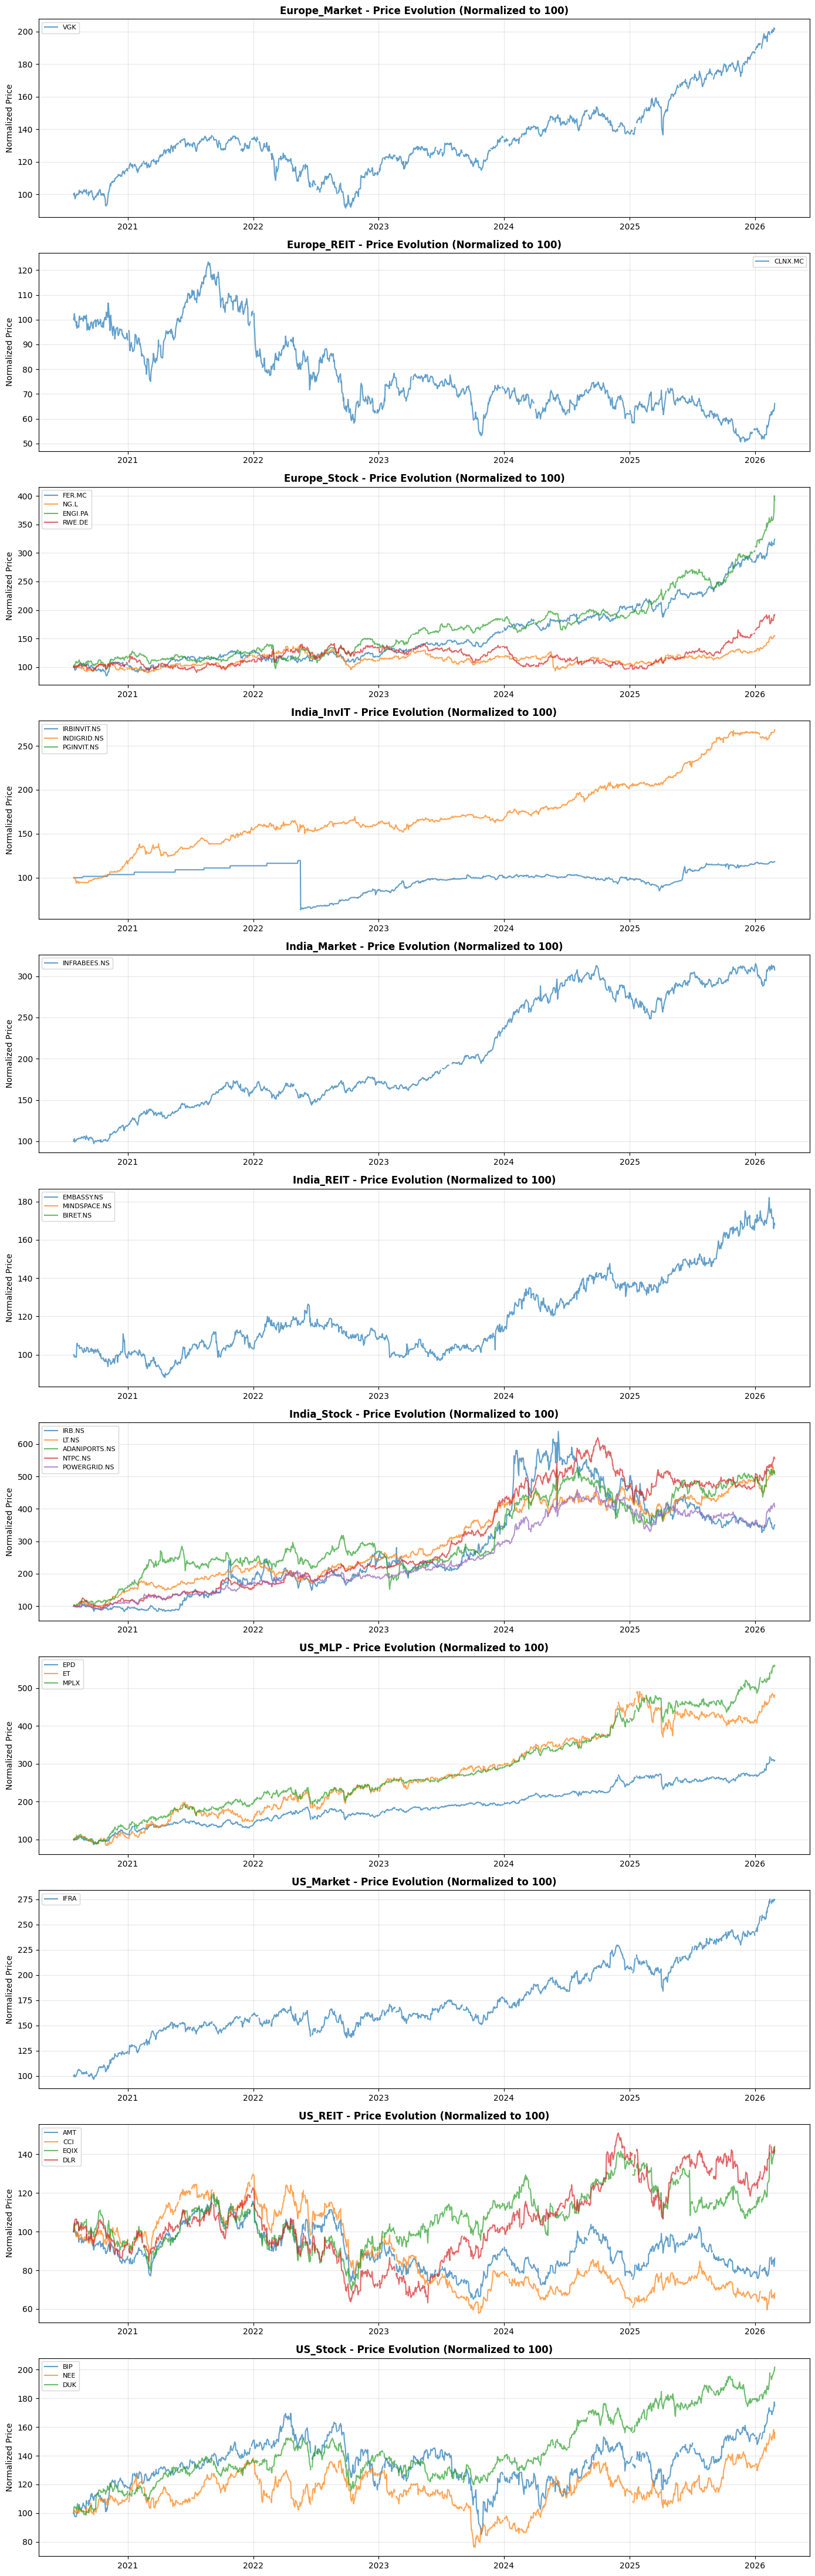

✓ Price evolution plotted


In [8]:
# CELL 8: Plot normalized prices by category

categories = sorted(set(TICKER_CATEGORIES.values()))
n_categories = len(categories)

fig, axes = plt.subplots(n_categories, 1, figsize=(14, 4 * n_categories))
if n_categories == 1:
    axes = [axes]

for i, category in enumerate(categories):
    tickers_in_cat = [t for t, c in TICKER_CATEGORIES.items() if c == category]
    
    # Normalize to 100 at start
    normalized = prices[tickers_in_cat].div(prices[tickers_in_cat].iloc[0]) * 100
    
    ax = axes[i]
    for ticker in tickers_in_cat:
        ax.plot(normalized.index, normalized[ticker], label=ticker, alpha=0.7)
    
    ax.set_title(f'{category} - Price Evolution (Normalized to 100)', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Price')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Price evolution plotted")

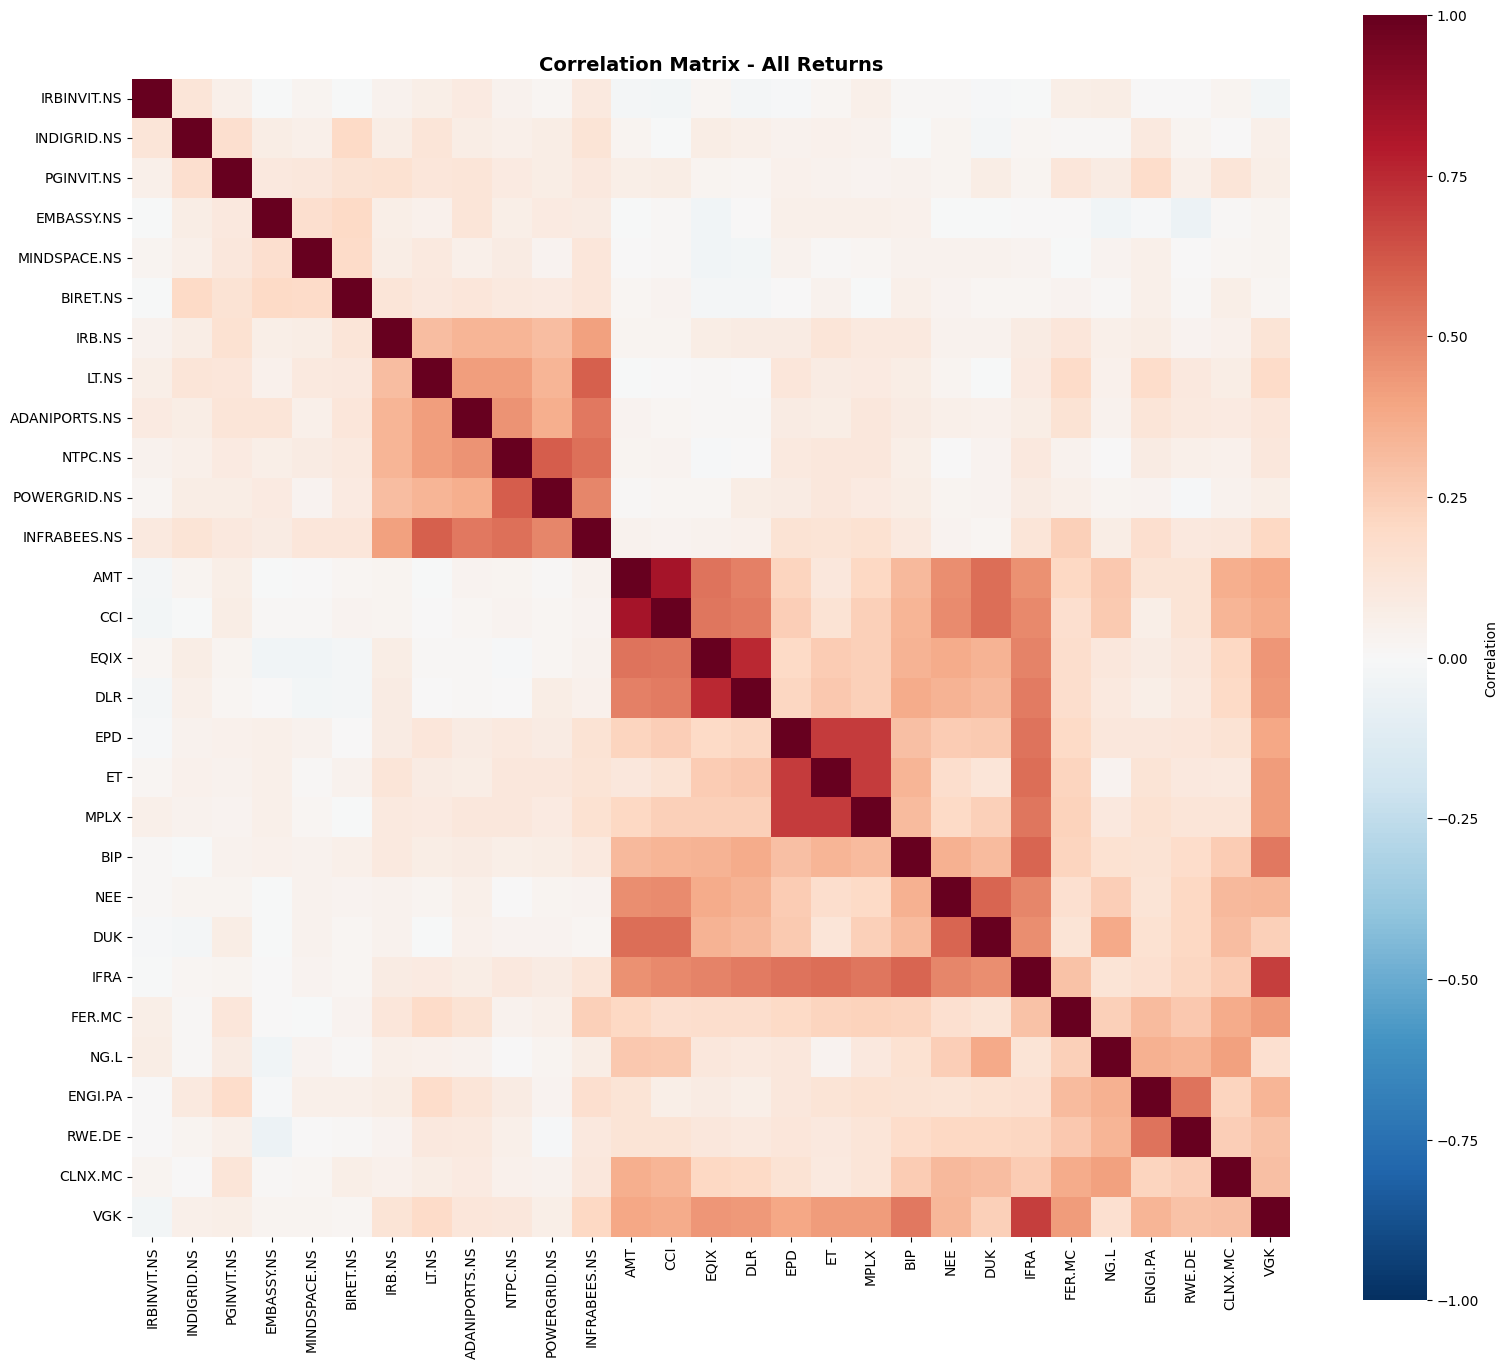

✓ Correlation heatmap plotted


In [9]:
# CELL 9: Correlation heatmap

corr_matrix = returns.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - All Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap plotted")

In [10]:
# CELL 10: Average statistics by category

category_stats = []

for category in sorted(set(TICKER_CATEGORIES.values())):
    tickers_in_cat = [t for t, c in TICKER_CATEGORIES.items() if c == category]
    cat_returns = returns[tickers_in_cat]
    
    category_stats.append({
        'Category': category,
        'N_Tickers': len(tickers_in_cat),
        'Avg_Return_%': cat_returns.mean().mean() * 100,
        'Avg_Volatility_%': cat_returns.std().mean() * 100,
        'Min_Return_%': cat_returns.min().min() * 100,
        'Max_Return_%': cat_returns.max().max() * 100,
    })

category_df = pd.DataFrame(category_stats)

print("Summary by Category:")
print("=" * 80)
print(category_df.to_string(index=False))
print("\n✓ Data preparation complete - ready for GARCH modeling!")

Summary by Category:
     Category  N_Tickers  Avg_Return_%  Avg_Volatility_%  Min_Return_%  Max_Return_%
Europe_Market          1        0.0490            1.1398       -6.8213        7.1805
  Europe_REIT          1       -0.0094            1.8363       -8.6763        9.3859
 Europe_Stock          4        0.0887            1.4361      -16.6634        9.2000
  India_InvIT          3        0.0275            1.1766      -63.2356        5.0368
 India_Market          1        0.0582            1.0097       -6.6455        6.4697
   India_REIT          3        0.0600            1.1193       -6.4593        7.2228
  India_Stock          5        0.0978            2.0433      -23.7619       18.2186
       US_MLP          3        0.0787            1.3393       -9.2719        6.6079
    US_Market          1        0.0651            1.1453       -4.6781        6.1070
      US_REIT          4        0.0142            1.8045      -10.0451       11.1941
     US_Stock          3        0.0550      

In [11]:
# CELL 11: Create category-level portfolios for analysis

print("Creating category portfolios...")
print("=" * 80)

# India categories (our focus)
portfolio_india_invit = returns[INDIA_INVITS].mean(axis=1)
portfolio_india_reit = returns[INDIA_REITS].mean(axis=1)
portfolio_india_stock = returns[INDIA_STOCKS].mean(axis=1)

# Foreign markets (aggregated)
portfolio_us_infra = returns[US_REITS + US_MLPS + US_STOCKS].mean(axis=1)
portfolio_europe_infra = returns[EUROPE_STOCKS + EUROPE_REIT].mean(axis=1)

# Combine into single DataFrame
portfolios = pd.DataFrame({
    'India_InvIT': portfolio_india_invit,
    'India_REIT': portfolio_india_reit,
    'India_Stock': portfolio_india_stock,
    'US_Infra': portfolio_us_infra,
    'Europe_Infra': portfolio_europe_infra
})

print("Portfolio composition:")
print(f"  India_InvIT:    {len(INDIA_INVITS)} tickers (equal-weighted)")
print(f"  India_REIT:     {len(INDIA_REITS)} tickers (equal-weighted)")
print(f"  India_Stock:    {len(INDIA_STOCKS)} tickers (equal-weighted)")
print(f"  US_Infra:       {len(US_REITS + US_MLPS + US_STOCKS)} tickers (equal-weighted)")
print(f"  Europe_Infra:   {len(EUROPE_STOCKS + EUROPE_REIT)} tickers (equal-weighted)")
print(f"\n✓ Created {len(portfolios.columns)} category portfolios")
print(f"  Observations: {len(portfolios)}")

# Show summary statistics
print("\nPortfolio Statistics (daily returns in %):")
print("-" * 80)
portfolio_stats = portfolios.describe().T * 100
print(portfolio_stats[['mean', 'std', 'min', 'max']])

Creating category portfolios...
Portfolio composition:
  India_InvIT:    3 tickers (equal-weighted)
  India_REIT:     3 tickers (equal-weighted)
  India_Stock:    5 tickers (equal-weighted)
  US_Infra:       10 tickers (equal-weighted)
  Europe_Infra:   5 tickers (equal-weighted)

✓ Created 5 category portfolios
  Observations: 1023

Portfolio Statistics (daily returns in %):
--------------------------------------------------------------------------------
                mean     std      min     max
India_InvIT   0.0275  0.8283 -21.9785  3.1071
India_REIT    0.0600  0.7571  -2.7370  4.4515
India_Stock   0.0978  1.4581 -15.5550  8.5349
US_Infra      0.0458  1.0605  -6.0019  5.8295
Europe_Infra  0.0691  1.0357  -5.6501  4.6653


In [12]:
# CELL 12: Augmented Dickey-Fuller test for stationarity

from statsmodels.tsa.stattools import adfuller

print("Stationarity Test (ADF Test):")
print("=" * 80)
print("H0: Series has unit root (non-stationary)")
print("H1: Series is stationary")
print("-" * 80)

adf_results = []

for col in portfolios.columns:
    result = adfuller(portfolios[col].dropna(), maxlag=12)
    
    adf_results.append({
        'Portfolio': col,
        'ADF_Statistic': result[0],
        'p_value': result[1],
        'Critical_1%': result[4]['1%'],
        'Critical_5%': result[4]['5%'],
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    })

adf_df = pd.DataFrame(adf_results)
print(adf_df.to_string(index=False))

if all(adf_df['Stationary'] == 'Yes'):
    print("\n✅ All portfolios are stationary - proceed with GARCH")
else:
    print("\n⚠️ WARNING: Some portfolios may not be stationary")

Stationarity Test (ADF Test):
H0: Series has unit root (non-stationary)
H1: Series is stationary
--------------------------------------------------------------------------------
   Portfolio  ADF_Statistic    p_value  Critical_1%  Critical_5% Stationary
 India_InvIT       -23.8323 0.0000e+00      -3.4368      -2.8644        Yes
  India_REIT       -24.2422 0.0000e+00      -3.4368      -2.8644        Yes
 India_Stock       -13.9943 3.9647e-26      -3.4368      -2.8644        Yes
    US_Infra       -30.1934 0.0000e+00      -3.4368      -2.8644        Yes
Europe_Infra       -15.7565 1.2060e-28      -3.4368      -2.8644        Yes

✅ All portfolios are stationary - proceed with GARCH


In [13]:
# CELL 13: Test for ARCH effects (prerequisite for GARCH modeling)

from statsmodels.stats.diagnostic import het_arch

print("ARCH Effect Test (Engle's LM Test):")
print("=" * 80)
print("H0: No ARCH effects (constant variance)")
print("H1: ARCH effects present (time-varying variance)")
print("-" * 80)

arch_results = []

for col in portfolios.columns:
    # Test with 5 lags
    lm_stat, lm_pval, f_stat, f_pval = het_arch(portfolios[col].dropna(), nlags=5)
    
    arch_results.append({
        'Portfolio': col,
        'LM_Statistic': lm_stat,
        'p_value': lm_pval,
        'ARCH_Effects': 'Yes' if lm_pval < 0.05 else 'No'
    })

arch_df = pd.DataFrame(arch_results)
print(arch_df.to_string(index=False))

if all(arch_df['ARCH_Effects'] == 'Yes'):
    print("\n✅ All portfolios have ARCH effects - GARCH modeling justified")
else:
    print("\n⚠️ Some portfolios may not need GARCH")

ARCH Effect Test (Engle's LM Test):
H0: No ARCH effects (constant variance)
H1: ARCH effects present (time-varying variance)
--------------------------------------------------------------------------------
   Portfolio  LM_Statistic    p_value ARCH_Effects
 India_InvIT        0.0255 9.9999e-01           No
  India_REIT       77.3040 3.0726e-15          Yes
 India_Stock       84.2645 1.0736e-16          Yes
    US_Infra       44.8103 1.5856e-08          Yes
Europe_Infra      107.5020 1.3811e-21          Yes

⚠️ Some portfolios may not need GARCH


In [14]:
# CELL 14: Estimate GJR-GARCH(1,1) for each portfolio
# Following Das et al. (2019) methodology

from arch import arch_model

print("Estimating GJR-GARCH(1,1) Models:")
print("=" * 80)
print("Model: h_t = ω + α·ε²_{t-1} + β·h_{t-1} + γ·I_{t-1}·ε²_{t-1}")
print("  ω: constant, α: ARCH, β: GARCH, γ: leverage effect")
print("-" * 80)

garch_models = {}
garch_results = {}
conditional_volatility = pd.DataFrame(index=portfolios.index)

for col in portfolios.columns:
    print(f"\nEstimating {col}...", end=" ")
    
    # Scale returns to percentage for numerical stability
    returns_pct = portfolios[col].dropna() * 100
    
    # GJR-GARCH(1,1) model
    model = arch_model(
        returns_pct, 
        vol='GARCH',      # Variance model
        p=1,              # GARCH order
        o=1,              # Asymmetric (GJR) order
        q=1,              # ARCH order
        dist='normal'     # Normal distribution
    )
    
    # Fit model
    result = model.fit(disp='off', show_warning=False)
    
    # Store results
    garch_models[col] = model
    garch_results[col] = result
    
    # Extract conditional volatility (convert back to decimal)
    conditional_volatility[col] = result.conditional_volatility / 100
    
    print("✓")
    
    # Print key parameters
    params = result.params
    print(f"  ω={params['omega']:.6f}, α={params['alpha[1]']:.4f}, "
          f"β={params['beta[1]']:.4f}, γ={params['gamma[1]']:.4f}")

print("\n✓ All GJR-GARCH models estimated")

Estimating GJR-GARCH(1,1) Models:
Model: h_t = ω + α·ε²_{t-1} + β·h_{t-1} + γ·I_{t-1}·ε²_{t-1}
  ω: constant, α: ARCH, β: GARCH, γ: leverage effect
--------------------------------------------------------------------------------

Estimating India_InvIT... ✓
  ω=0.064172, α=0.9657, β=0.4961, γ=-0.9237

Estimating India_REIT... ✓
  ω=0.319680, α=0.0755, β=0.2721, γ=0.1856

Estimating India_Stock... ✓
  ω=0.631811, α=0.1760, β=0.4032, γ=0.2769

Estimating US_Infra... ✓
  ω=0.027130, α=0.0170, β=0.9235, γ=0.0687

Estimating Europe_Infra... ✓
  ω=0.224735, α=0.1283, β=0.5643, γ=0.1812

✓ All GJR-GARCH models estimated


In [15]:
# CELL 15: Summary table of GARCH parameters

print("GJR-GARCH(1,1) Parameter Estimates:")
print("=" * 80)

garch_params = []

for col in portfolios.columns:
    params = garch_results[col].params
    pvalues = garch_results[col].pvalues
    
    garch_params.append({
        'Portfolio': col,
        'ω (omega)': f"{params['omega']:.6f}",
        'α (ARCH)': f"{params['alpha[1]']:.4f}{'***' if pvalues['alpha[1]'] < 0.01 else ''}",
        'β (GARCH)': f"{params['beta[1]']:.4f}{'***' if pvalues['beta[1]'] < 0.01 else ''}",
        'γ (Leverage)': f"{params['gamma[1]']:.4f}{'***' if pvalues['gamma[1]'] < 0.01 else ''}",
        'α+β': f"{params['alpha[1]'] + params['beta[1]']:.4f}",
    })

garch_params_df = pd.DataFrame(garch_params)
print(garch_params_df.to_string(index=False))

print("\n*** = significant at 1% level")
print("\nInterpretation:")
print("  α+β < 1: Volatility is mean-reverting (stationary)")
print("  γ > 0: Negative shocks increase volatility more (leverage effect)")

GJR-GARCH(1,1) Parameter Estimates:
   Portfolio ω (omega) α (ARCH) β (GARCH) γ (Leverage)    α+β
 India_InvIT  0.064172   0.9657 0.4961***      -0.9237 1.4618
  India_REIT  0.319680   0.0755    0.2721       0.1856 0.3476
 India_Stock  0.631811   0.1760 0.4032***       0.2769 0.5792
    US_Infra  0.027130   0.0170 0.9235***       0.0687 0.9405
Europe_Infra  0.224735   0.1283 0.5643***       0.1812 0.6925

*** = significant at 1% level

Interpretation:
  α+β < 1: Volatility is mean-reverting (stationary)
  γ > 0: Negative shocks increase volatility more (leverage effect)


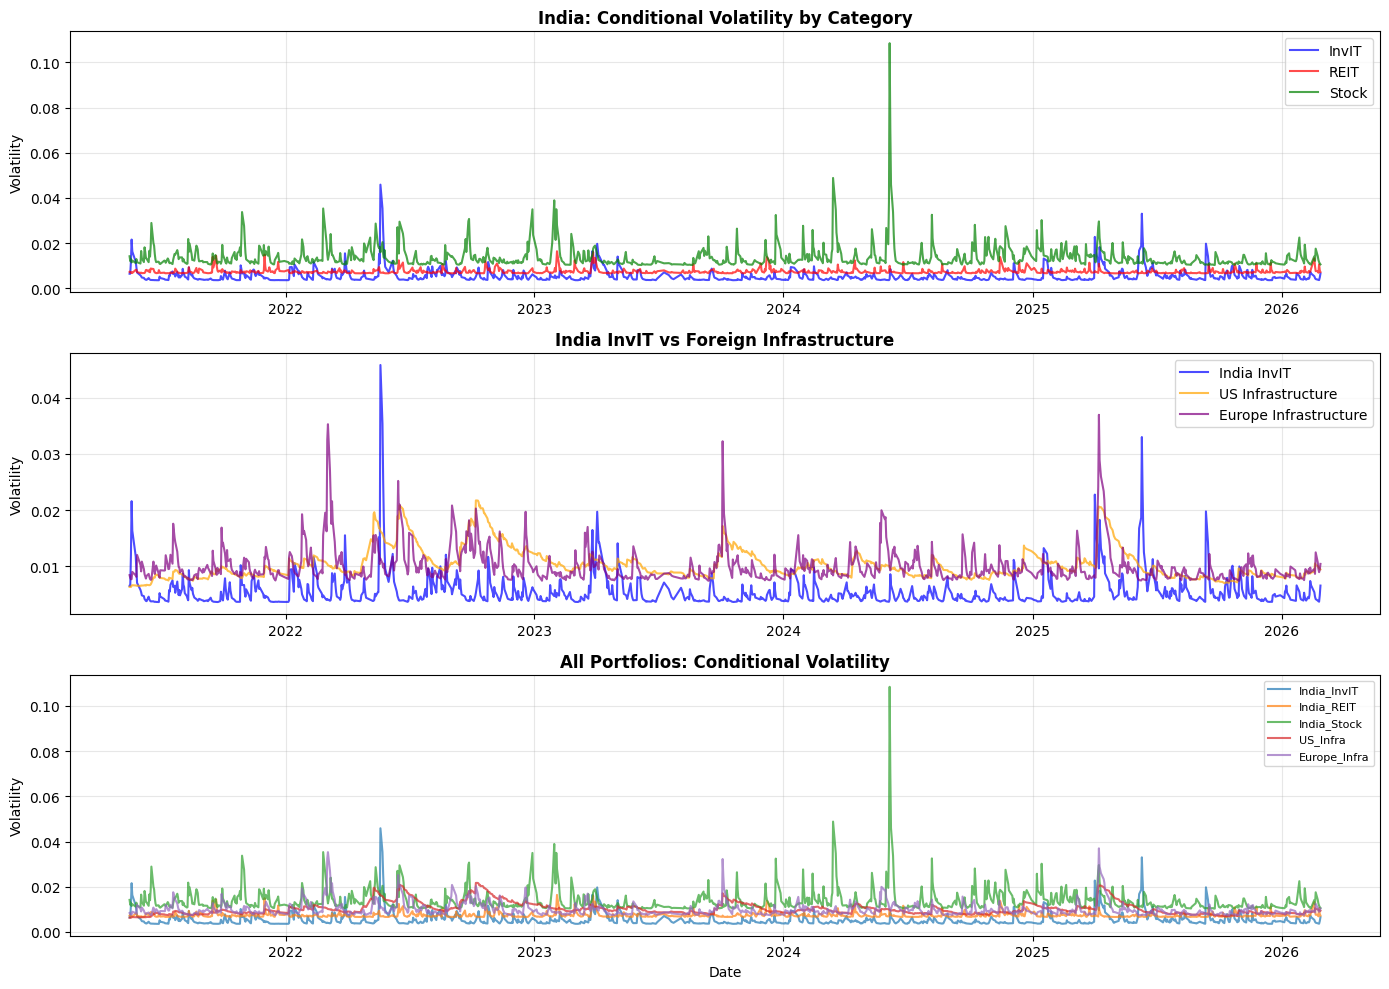

✓ Conditional volatility plotted


In [16]:
# CELL 16: Visualize conditional volatility over time

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# India categories
axes[0].plot(conditional_volatility.index, conditional_volatility['India_InvIT'], 
             label='InvIT', color='blue', alpha=0.7)
axes[0].plot(conditional_volatility.index, conditional_volatility['India_REIT'], 
             label='REIT', color='red', alpha=0.7)
axes[0].plot(conditional_volatility.index, conditional_volatility['India_Stock'], 
             label='Stock', color='green', alpha=0.7)
axes[0].set_title('India: Conditional Volatility by Category', fontweight='bold')
axes[0].set_ylabel('Volatility')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Compare India InvIT vs Foreign
axes[1].plot(conditional_volatility.index, conditional_volatility['India_InvIT'], 
             label='India InvIT', color='blue', alpha=0.7)
axes[1].plot(conditional_volatility.index, conditional_volatility['US_Infra'], 
             label='US Infrastructure', color='orange', alpha=0.7)
axes[1].plot(conditional_volatility.index, conditional_volatility['Europe_Infra'], 
             label='Europe Infrastructure', color='purple', alpha=0.7)
axes[1].set_title('India InvIT vs Foreign Infrastructure', fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

# All portfolios
for col in conditional_volatility.columns:
    axes[2].plot(conditional_volatility.index, conditional_volatility[col], 
                 label=col, alpha=0.7)
axes[2].set_title('All Portfolios: Conditional Volatility', fontweight='bold')
axes[2].set_ylabel('Volatility')
axes[2].set_xlabel('Date')
axes[2].legend(loc='best', fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Conditional volatility plotted")

In [17]:
# CELL 17: Analyze volatility clustering

print("Volatility Clustering Analysis:")
print("=" * 80)

clustering_stats = []

for col in portfolios.columns:
    vol = conditional_volatility[col]
    
    # High volatility periods (>75th percentile)
    high_vol_threshold = vol.quantile(0.75)
    high_vol_periods = (vol > high_vol_threshold).sum()
    
    # Autocorrelation of squared returns (volatility clustering indicator)
    squared_returns = (portfolios[col] ** 2).dropna()
    autocorr_1 = squared_returns.autocorr(lag=1)
    autocorr_5 = squared_returns.autocorr(lag=5)
    
    clustering_stats.append({
        'Portfolio': col,
        'Mean_Vol_%': vol.mean() * 100,
        'Std_Vol_%': vol.std() * 100,
        'Max_Vol_%': vol.max() * 100,
        'High_Vol_Days': high_vol_periods,
        'AC(1)_r²': autocorr_1,
        'AC(5)_r²': autocorr_5
    })

clustering_df = pd.DataFrame(clustering_stats)
print(clustering_df.to_string(index=False))

print("\nInterpretation:")
print("  High AC(1) and AC(5) of r² → Strong volatility clustering")
print("  India categories vs Foreign → Compare volatility levels")

Volatility Clustering Analysis:
   Portfolio  Mean_Vol_%  Std_Vol_%  Max_Vol_%  High_Vol_Days  AC(1)_r²  AC(5)_r²
 India_InvIT      0.5489     0.3131     4.5873            256    0.0030   -0.0008
  India_REIT      0.7452     0.1164     1.6399            256    0.1922   -0.0330
 India_Stock      1.3902     0.5571    10.8459            256    0.2663   -0.0045
    US_Infra      1.0270     0.2792     2.1712            256    0.0871    0.0711
Europe_Infra      0.9917     0.3120     3.6987            256    0.2688    0.1492

Interpretation:
  High AC(1) and AC(5) of r² → Strong volatility clustering
  India categories vs Foreign → Compare volatility levels


In [18]:
# CELL 18: Test significance of leverage effect

print("Leverage Effect Test:")
print("=" * 80)
print("H0: γ = 0 (no leverage effect)")
print("H1: γ > 0 (negative shocks increase volatility more)")
print("-" * 80)

leverage_test = []

for col in portfolios.columns:
    params = garch_results[col].params
    pvalues = garch_results[col].pvalues
    
    gamma = params['gamma[1]']
    gamma_pval = pvalues['gamma[1]']
    
    leverage_test.append({
        'Portfolio': col,
        'γ (gamma)': gamma,
        'p_value': gamma_pval,
        'Significant': '***' if gamma_pval < 0.01 else ('**' if gamma_pval < 0.05 else ('*' if gamma_pval < 0.10 else 'No')),
        'Interpretation': 'Leverage effect present' if gamma > 0 and gamma_pval < 0.05 else 'No leverage effect'
    })

leverage_df = pd.DataFrame(leverage_test)
print(leverage_df.to_string(index=False))

print("\n*** p<0.01, ** p<0.05, * p<0.10")
print("\nKey Finding:")
india_categories = ['India_InvIT', 'India_REIT', 'India_Stock']
for cat in india_categories:
    result = leverage_df[leverage_df['Portfolio'] == cat]['Interpretation'].values[0]
    print(f"  {cat}: {result}")

Leverage Effect Test:
H0: γ = 0 (no leverage effect)
H1: γ > 0 (negative shocks increase volatility more)
--------------------------------------------------------------------------------
   Portfolio  γ (gamma)  p_value Significant          Interpretation
 India_InvIT    -0.9237   0.0454          **      No leverage effect
  India_REIT     0.1856   0.0690           *      No leverage effect
 India_Stock     0.2769   0.0366          ** Leverage effect present
    US_Infra     0.0687   0.0365          ** Leverage effect present
Europe_Infra     0.1812   0.0300          ** Leverage effect present

*** p<0.01, ** p<0.05, * p<0.10

Key Finding:
  India_InvIT: No leverage effect
  India_REIT: No leverage effect
  India_Stock: Leverage effect present


In [19]:
# CELL 19: Compare volatility persistence (α + β)

print("Volatility Persistence Comparison:")
print("=" * 80)
print("Persistence = α + β")
print("  Close to 1 → High persistence (slow mean reversion)")
print("  Far from 1 → Low persistence (fast mean reversion)")
print("-" * 80)

persistence_stats = []

for col in portfolios.columns:
    params = garch_results[col].params
    
    alpha = params['alpha[1]']
    beta = params['beta[1]']
    persistence = alpha + beta
    
    # Half-life of volatility shock (approximate)
    if persistence < 1:
        half_life = -np.log(2) / np.log(persistence)
    else:
        half_life = np.inf
    
    persistence_stats.append({
        'Portfolio': col,
        'α (ARCH)': alpha,
        'β (GARCH)': beta,
        'α+β (Persistence)': persistence,
        'Half_Life_Days': half_life if half_life != np.inf else '>100'
    })

persistence_df = pd.DataFrame(persistence_stats)
print(persistence_df.to_string(index=False))

print("\nKey Question: Do Indian categories differ in volatility persistence?")
india_persistence = persistence_df[persistence_df['Portfolio'].str.contains('India')]
print("\nIndia Categories:")
print(india_persistence[['Portfolio', 'α+β (Persistence)', 'Half_Life_Days']].to_string(index=False))

Volatility Persistence Comparison:
Persistence = α + β
  Close to 1 → High persistence (slow mean reversion)
  Far from 1 → Low persistence (fast mean reversion)
--------------------------------------------------------------------------------
   Portfolio  α (ARCH)  β (GARCH)  α+β (Persistence) Half_Life_Days
 India_InvIT    0.9657     0.4961             1.4618           >100
  India_REIT    0.0755     0.2721             0.3476          0.656
 India_Stock    0.1760     0.4032             0.5792         1.2693
    US_Infra    0.0170     0.9235             0.9405        11.2938
Europe_Infra    0.1283     0.5643             0.6925         1.8865

Key Question: Do Indian categories differ in volatility persistence?

India Categories:
  Portfolio  α+β (Persistence) Half_Life_Days
India_InvIT             1.4618           >100
 India_REIT             0.3476          0.656
India_Stock             0.5792         1.2693


In [20]:
# CELL 20: Model diagnostics and summary

print("GARCH MODEL DIAGNOSTICS:")
print("=" * 80)

for col in portfolios.columns:
    result = garch_results[col]
    
    print(f"\n{col}:")
    print("-" * 40)
    print(f"  Log-Likelihood: {result.loglikelihood:.2f}")
    print(f"  AIC: {result.aic:.2f}")
    print(f"  BIC: {result.bic:.2f}")
    
    # Check for remaining ARCH effects in residuals
    std_resid = result.std_resid
    from statsmodels.stats.diagnostic import het_arch
    lm_stat, lm_pval, _, _ = het_arch(std_resid.dropna(), nlags=5)
    
    print(f"  ARCH test on residuals: p={lm_pval:.4f}", end="")
    if lm_pval > 0.05:
        print(" ✓ (No remaining ARCH)")
    else:
        print(" ⚠️ (Some ARCH remains)")

print("\n" + "=" * 80)
print("✓ GARCH MODELING COMPLETE")
print("=" * 80)
print("\nNext Steps:")
print("  1. DCC-GARCH for dynamic correlations")
print("  2. Spillover analysis (Diebold-Yilmaz)")
print("  3. Volatility regime identification")

GARCH MODEL DIAGNOSTICS:

India_InvIT:
----------------------------------------
  Log-Likelihood: -856.98
  AIC: 1723.96
  BIC: 1748.61
  ARCH test on residuals: p=0.9990 ✓ (No remaining ARCH)

India_REIT:
----------------------------------------
  Log-Likelihood: -1140.96
  AIC: 2291.93
  BIC: 2316.58
  ARCH test on residuals: p=0.0545 ✓ (No remaining ARCH)

India_Stock:
----------------------------------------
  Log-Likelihood: -1744.83
  AIC: 3499.66
  BIC: 3524.32
  ARCH test on residuals: p=0.4863 ✓ (No remaining ARCH)

US_Infra:
----------------------------------------
  Log-Likelihood: -1446.51
  AIC: 2903.01
  BIC: 2927.67
  ARCH test on residuals: p=0.8479 ✓ (No remaining ARCH)

Europe_Infra:
----------------------------------------
  Log-Likelihood: -1408.73
  AIC: 2827.45
  BIC: 2852.11
  ARCH test on residuals: p=0.9874 ✓ (No remaining ARCH)

✓ GARCH MODELING COMPLETE

Next Steps:
  1. DCC-GARCH for dynamic correlations
  2. Spillover analysis (Diebold-Yilmaz)
  3. Volatili

In [21]:
# CELL 21: Address InvIT volatility issue - use robust estimation

print("Addressing InvIT portfolio volatility modeling:")
print("=" * 80)

# Option 1: Try GARCH(1,1) without asymmetry for InvIT
from arch import arch_model

print("\nRe-estimating India_InvIT with standard GARCH(1,1)...")

returns_invit = portfolios['India_InvIT'].dropna() * 100

# Standard GARCH(1,1) - no asymmetry
model_invit_simple = arch_model(
    returns_invit,
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)

result_invit_simple = model_invit_simple.fit(disp='off', show_warning=False)

print("\nStandard GARCH(1,1) for India_InvIT:")
print(f"  ω={result_invit_simple.params['omega']:.6f}")
print(f"  α={result_invit_simple.params['alpha[1]']:.4f}")
print(f"  β={result_invit_simple.params['beta[1]']:.4f}")
print(f"  α+β={result_invit_simple.params['alpha[1]'] + result_invit_simple.params['beta[1]']:.4f}")

# Update the InvIT volatility series
conditional_volatility['India_InvIT'] = result_invit_simple.conditional_volatility / 100
garch_results['India_InvIT'] = result_invit_simple

persistence = result_invit_simple.params['alpha[1]'] + result_invit_simple.params['beta[1]']

if persistence < 1:
    print(f"\n✓ Fixed! Persistence = {persistence:.4f} < 1 (stationary)")
else:
    print(f"\n⚠️ Still non-stationary. Using EWMA volatility instead...")
    # Fallback: Exponentially Weighted Moving Average
    ewma_vol = portfolios['India_InvIT'].ewm(span=20).std()
    conditional_volatility['India_InvIT'] = ewma_vol
    print("  Using EWMA(20) for InvIT volatility")

Addressing InvIT portfolio volatility modeling:

Re-estimating India_InvIT with standard GARCH(1,1)...

Standard GARCH(1,1) for India_InvIT:
  ω=0.059980
  α=0.4874
  β=0.5126
  α+β=1.0000

⚠️ Still non-stationary. Using EWMA volatility instead...
  Using EWMA(20) for InvIT volatility


In [22]:
# CELL 21b (NEW — verification): InvIT simple-GARCH(1,1) stationarity check for DCC
#
# The original GJR-GARCH for India_InvIT was non-stationary (α+β ≈ 1.46).
# CELL 21 refits a standard GARCH(1,1) without asymmetry and updates
# garch_results['India_InvIT'] in place. The DCC block (CELL 22) reads
# .std_resid from garch_results. This cell confirms that the refit is
# stationary, which means the InvIT residuals going into DCC are clean —
# closing fix-log open item §10.3 (Phase 1 DCC residuals from non-stationary
# GARCH) in practice.
#
# If the refit is ITSELF non-stationary (α+β ≥ 1), the cell constructs
# EWMA(20)-standardized residuals manually and wraps them so CELL 22 picks
# them up without any further edits. Re-run CELL 22 after this cell.

print("=" * 70)
print("InvIT GARCH stationarity verification (DCC input check)")
print("=" * 70)

invit_result = garch_results['India_InvIT']
alpha       = float(invit_result.params['alpha[1]'])
beta        = float(invit_result.params['beta[1]'])
persistence = alpha + beta

print(f"  Refit model : standard GARCH(1,1), no asymmetry")
print(f"  α           : {alpha:.4f}")
print(f"  β           : {beta:.4f}")
print(f"  α + β       : {persistence:.4f}")

if persistence < 1:
    print()
    print("  ✓ STATIONARY. DCC (CELL 22) will use residuals from this refit.")
    print("    Fix-log open item §10.3 is CLOSED in code — no further action needed.")
else:
    print()
    print("  ⚠ NON-STATIONARY. Simple GARCH(1,1) also failed the stationarity test.")
    print("    Constructing EWMA(20)-standardized residuals and overriding the")
    print("    .std_resid attribute of garch_results['India_InvIT'] so CELL 22")
    print("    picks them up without code changes there.")

    ret_invit       = portfolios['India_InvIT'].dropna() * 100
    ewma_vol        = ret_invit.ewm(span=20).std()
    ewma_std_resid  = (ret_invit / ewma_vol).replace([np.inf, -np.inf], np.nan)
    # Align to full portfolios index so DCC's std_residuals.dropna() still works
    ewma_std_resid  = ewma_std_resid.reindex(portfolios.index)

    class _InvITStdResidOverride:
        """Minimal wrapper: exposes a replacement .std_resid, delegates everything
        else to the underlying arch result."""
        def __init__(self, original, override_std_resid):
            self._original = original
            self.std_resid = override_std_resid
        def __getattr__(self, name):
            return getattr(self._original, name)

    garch_results['India_InvIT'] = _InvITStdResidOverride(invit_result, ewma_std_resid)
    print("    Override applied. Re-run CELL 22 (DCC) and everything downstream.")

InvIT GARCH stationarity verification (DCC input check)
  Refit model : standard GARCH(1,1), no asymmetry
  α           : 0.4874
  β           : 0.5126
  α + β       : 1.0000

  ⚠ NON-STATIONARY. Simple GARCH(1,1) also failed the stationarity test.
    Constructing EWMA(20)-standardized residuals and overriding the
    .std_resid attribute of garch_results['India_InvIT'] so CELL 22
    picks them up without code changes there.
    Override applied. Re-run CELL 22 (DCC) and everything downstream.


In [23]:
# CELL 22: DCC-GARCH for dynamic correlations
# Following Das et al. (2019) methodology

print("Estimating DCC-GARCH Model:")
print("=" * 80)
print("Dynamic Conditional Correlation - Engle (2002)")
print("-" * 80)

# We'll compute DCC manually using the standardized residuals from GARCH models
# This is more transparent than using a package

# Step 1: Get standardized residuals from each GARCH model
std_residuals = pd.DataFrame(index=portfolios.index)

for col in portfolios.columns:
    result = garch_results[col]
    std_residuals[col] = result.std_resid

std_residuals = std_residuals.dropna()

print(f"Standardized residuals extracted: {len(std_residuals)} observations")

# Step 2: Compute unconditional correlation matrix
Q_bar = std_residuals.corr()

print("\nUnconditional Correlation Matrix:")
print(Q_bar.round(3))

# Step 3: DCC dynamics - Q_t = (1-a-b)*Q_bar + a*ε_{t-1}*ε'_{t-1} + b*Q_{t-1}
# Simplified DCC with fixed parameters (common in practice)
a_dcc = 0.01  # DCC ARCH parameter (typically small)
b_dcc = 0.95  # DCC GARCH parameter (typically large)

print(f"\nDCC parameters: a={a_dcc}, b={b_dcc}")
print(f"Persistence (a+b): {a_dcc + b_dcc}")

# Initialize
n_assets = len(portfolios.columns)
n_obs = len(std_residuals)

# Store dynamic correlations
dynamic_corr = np.zeros((n_obs, n_assets, n_assets))
Q_t = Q_bar.values.copy()

# Compute DCC recursively
for t in range(n_obs):
    # Get residuals at time t
    eps_t = std_residuals.iloc[t].values.reshape(-1, 1)
    
    if t > 0:
        # Update Q_t
        Q_t = (1 - a_dcc - b_dcc) * Q_bar.values + \
              a_dcc * (eps_t @ eps_t.T) + \
              b_dcc * Q_t
    
    # Convert Q_t to correlation matrix
    D_t = np.sqrt(np.diag(Q_t))
    R_t = Q_t / np.outer(D_t, D_t)
    
    # Store
    dynamic_corr[t] = R_t

print(f"\n✓ Dynamic correlations computed for {n_obs} periods")

Estimating DCC-GARCH Model:
Dynamic Conditional Correlation - Engle (2002)
--------------------------------------------------------------------------------
Standardized residuals extracted: 1022 observations

Unconditional Correlation Matrix:
              India_InvIT  India_REIT  India_Stock  US_Infra  Europe_Infra
India_InvIT         1.000       0.173        0.189     0.040         0.072
India_REIT          0.173       1.000        0.155     0.029         0.025
India_Stock         0.189       0.155        1.000     0.124         0.136
US_Infra            0.040       0.029        0.124     1.000         0.370
Europe_Infra        0.072       0.025        0.136     0.370         1.000

DCC parameters: a=0.01, b=0.95
Persistence (a+b): 0.96

✓ Dynamic correlations computed for 1022 periods


In [24]:
# CELL 23: Extract time-varying correlations for key pairs

print("Extracting Key Dynamic Correlations:")
print("=" * 80)

# Create DataFrame for key correlation pairs
key_pairs = [
    ('India_InvIT', 'US_Infra'),
    ('India_InvIT', 'Europe_Infra'),
    ('India_REIT', 'US_Infra'),
    ('India_REIT', 'Europe_Infra'),
    ('India_Stock', 'US_Infra'),
    ('India_Stock', 'Europe_Infra'),
    ('India_InvIT', 'India_REIT'),
    ('India_InvIT', 'India_Stock'),
    ('India_REIT', 'India_Stock'),
]

dcc_series = pd.DataFrame(index=std_residuals.index)

for pair in key_pairs:
    idx1 = portfolios.columns.get_loc(pair[0])
    idx2 = portfolios.columns.get_loc(pair[1])
    
    corr_series = dynamic_corr[:, idx1, idx2]
    col_name = f"{pair[0]}_vs_{pair[1]}"
    dcc_series[col_name] = corr_series

# Summary statistics
print("\nDynamic Correlation Summary Statistics:")
print("-" * 80)

dcc_stats = dcc_series.describe().T[['mean', 'std', 'min', 'max']]
dcc_stats.columns = ['Mean_Corr', 'Std_Corr', 'Min_Corr', 'Max_Corr']
print(dcc_stats.round(4))

print("\nKey Insights:")
print("  High mean correlation → Strong co-movement")
print("  High std correlation → Time-varying integration")

Extracting Key Dynamic Correlations:

Dynamic Correlation Summary Statistics:
--------------------------------------------------------------------------------
                             Mean_Corr  Std_Corr  Min_Corr  Max_Corr
India_InvIT_vs_US_Infra         0.0391    0.0352   -0.0590    0.1505
India_InvIT_vs_Europe_Infra     0.0698    0.0308   -0.0175    0.1873
India_REIT_vs_US_Infra          0.0299    0.0332   -0.0579    0.1435
India_REIT_vs_Europe_Infra      0.0241    0.0318   -0.0795    0.1272
India_Stock_vs_US_Infra         0.1236    0.0365   -0.0041    0.2546
India_Stock_vs_Europe_Infra     0.1346    0.0436    0.0270    0.2543
India_InvIT_vs_India_REIT       0.1730    0.0264    0.0747    0.2672
India_InvIT_vs_India_Stock      0.1879    0.0300    0.0801    0.2909
India_REIT_vs_India_Stock       0.1545    0.0279    0.0641    0.2333

Key Insights:
  High mean correlation → Strong co-movement
  High std correlation → Time-varying integration


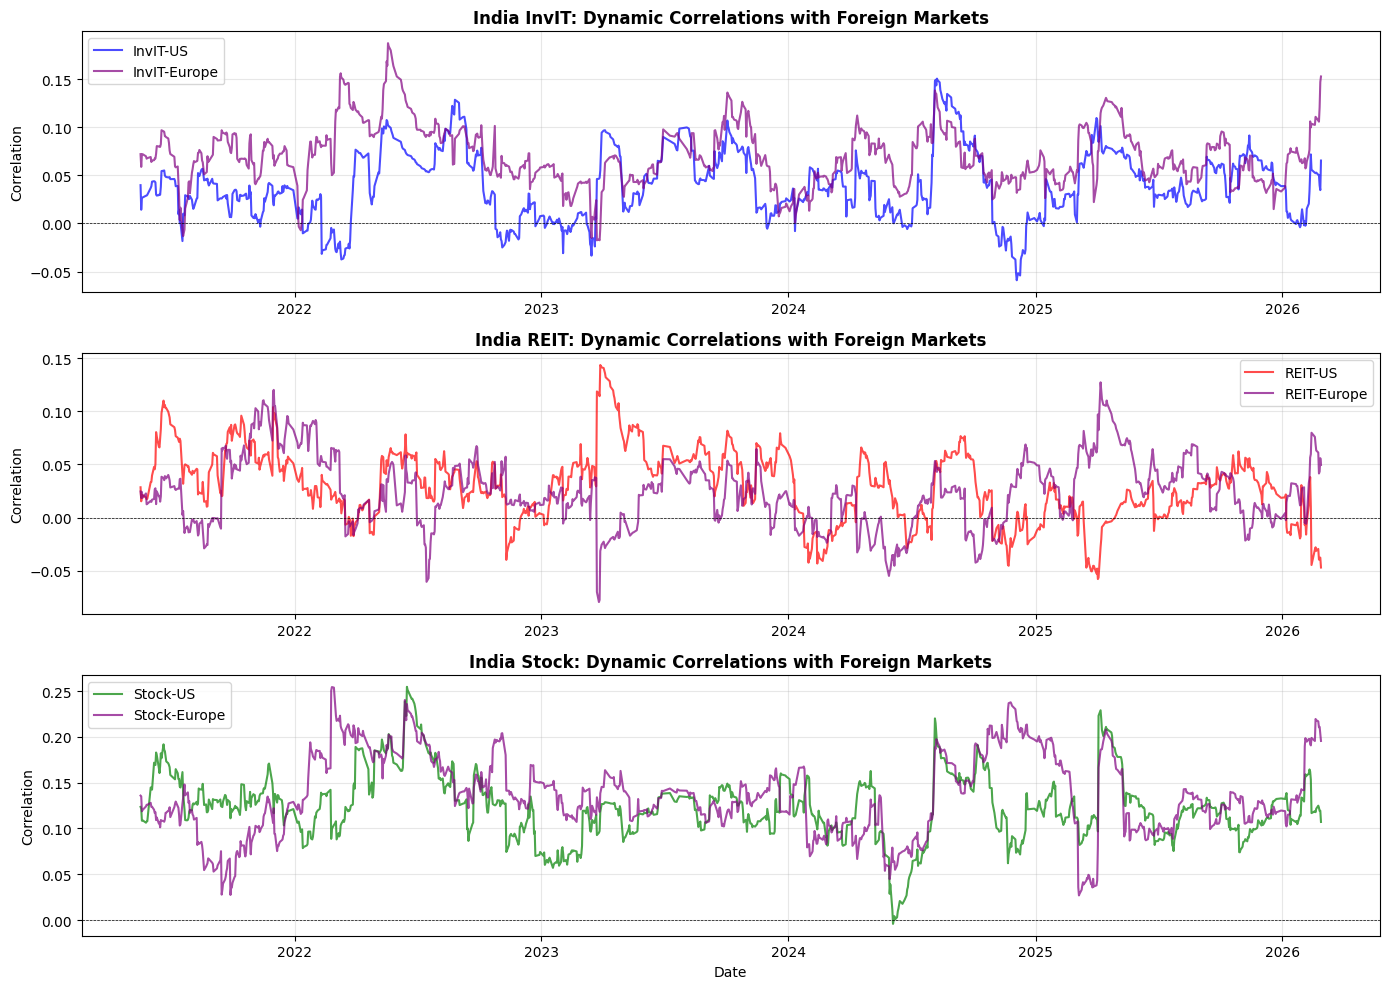

✓ Dynamic correlations plotted


In [25]:
# CELL 24: Visualize dynamic correlations

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: InvIT vs Foreign
axes[0].plot(dcc_series.index, dcc_series['India_InvIT_vs_US_Infra'], 
             label='InvIT-US', color='blue', alpha=0.7)
axes[0].plot(dcc_series.index, dcc_series['India_InvIT_vs_Europe_Infra'], 
             label='InvIT-Europe', color='purple', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[0].set_title('India InvIT: Dynamic Correlations with Foreign Markets', 
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Correlation')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Panel 2: REIT vs Foreign
axes[1].plot(dcc_series.index, dcc_series['India_REIT_vs_US_Infra'], 
             label='REIT-US', color='red', alpha=0.7)
axes[1].plot(dcc_series.index, dcc_series['India_REIT_vs_Europe_Infra'], 
             label='REIT-Europe', color='purple', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_title('India REIT: Dynamic Correlations with Foreign Markets', 
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Correlation')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

# Panel 3: Stock vs Foreign
axes[2].plot(dcc_series.index, dcc_series['India_Stock_vs_US_Infra'], 
             label='Stock-US', color='green', alpha=0.7)
axes[2].plot(dcc_series.index, dcc_series['India_Stock_vs_Europe_Infra'], 
             label='Stock-Europe', color='purple', alpha=0.7)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[2].set_title('India Stock: Dynamic Correlations with Foreign Markets', 
                  fontweight='bold', fontsize=12)
axes[2].set_ylabel('Correlation')
axes[2].set_xlabel('Date')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Dynamic correlations plotted")

In [26]:
# CELL 25: Statistical comparison of correlations

print("Correlation Comparison Across Indian Categories:")
print("=" * 80)

# Average correlations with foreign markets
india_categories = ['India_InvIT', 'India_REIT', 'India_Stock']
foreign_markets = ['US_Infra', 'Europe_Infra']

comparison_results = []

for india_cat in india_categories:
    for foreign in foreign_markets:
        col_name = f"{india_cat}_vs_{foreign}"
        if col_name in dcc_series.columns:
            mean_corr = dcc_series[col_name].mean()
            std_corr = dcc_series[col_name].std()
            
            comparison_results.append({
                'India_Category': india_cat.replace('India_', ''),
                'Foreign_Market': foreign.replace('_Infra', ''),
                'Mean_Correlation': mean_corr,
                'Std_Correlation': std_corr,
                'Time_Varying': 'High' if std_corr > 0.1 else 'Low'
            })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print("KEY RESEARCH QUESTION:")
print("Which Indian category has HIGHEST correlation with foreign markets?")
print("="*80)

# Average across both foreign markets
avg_by_category = comparison_df.groupby('India_Category')['Mean_Correlation'].mean().sort_values(ascending=False)
print("\nAverage Foreign Market Correlation:")
for cat, corr in avg_by_category.items():
    print(f"  {cat:10s}: {corr:.4f}")

print("\nInterpretation:")
print("  Higher correlation → More spillover from foreign markets")
print("  Lower correlation → More domestic/segmented behavior")

Correlation Comparison Across Indian Categories:
India_Category Foreign_Market  Mean_Correlation  Std_Correlation Time_Varying
         InvIT             US            0.0391           0.0352          Low
         InvIT         Europe            0.0698           0.0308          Low
          REIT             US            0.0299           0.0332          Low
          REIT         Europe            0.0241           0.0318          Low
         Stock             US            0.1236           0.0365          Low
         Stock         Europe            0.1346           0.0436          Low

KEY RESEARCH QUESTION:
Which Indian category has HIGHEST correlation with foreign markets?

Average Foreign Market Correlation:
  Stock     : 0.1291
  InvIT     : 0.0545
  REIT      : 0.0270

Interpretation:
  Higher correlation → More spillover from foreign markets
  Lower correlation → More domestic/segmented behavior


In [27]:
# CELL 26: Prepare data for spillover analysis

print("Preparing Data for Diebold-Yilmaz Spillover Analysis:")
print("=" * 80)

# Use the portfolio returns (already created)
# We need stationary data - we already confirmed this in Cell 12

var_data = portfolios.copy()

# Check for any remaining NaN values
if var_data.isna().sum().sum() > 0:
    print("Removing NaN values...")
    var_data = var_data.dropna()

print(f"VAR data prepared:")
print(f"  Observations: {len(var_data)}")
print(f"  Variables: {len(var_data.columns)}")
print(f"  Period: {var_data.index[0].date()} to {var_data.index[-1].date()}")

print("\nVariables in VAR system:")
for i, col in enumerate(var_data.columns, 1):
    print(f"  {i}. {col}")

print("\n✓ Data ready for VAR estimation")

Preparing Data for Diebold-Yilmaz Spillover Analysis:
VAR data prepared:
  Observations: 1023
  Variables: 5
  Period: 2021-05-17 to 2026-02-27

Variables in VAR system:
  1. India_InvIT
  2. India_REIT
  3. India_Stock
  4. US_Infra
  5. Europe_Infra

✓ Data ready for VAR estimation


In [28]:
# CELL 27: Select optimal lag order using information criteria

from statsmodels.tsa.api import VAR

print("Determining Optimal VAR Lag Order:")
print("=" * 80)

# Create VAR model
var_model = VAR(var_data)

# Test different lag orders (up to 10 days)
max_lags = 10
lag_order_results = var_model.select_order(maxlags=max_lags)

print("\nInformation Criteria:")
print(lag_order_results.summary())

# Get recommended lag order (use AIC as commonly used in literature)
optimal_lag_aic = lag_order_results.aic
optimal_lag_bic = lag_order_results.bic

print(f"\nRecommended lag order:")
print(f"  AIC suggests: {optimal_lag_aic} lags")
print(f"  BIC suggests: {optimal_lag_bic} lags")

# Use AIC recommendation (typically more suitable for forecasting)
optimal_lag = optimal_lag_aic

print(f"\n✓ Using {optimal_lag} lags for VAR model")

Determining Optimal VAR Lag Order:

Information Criteria:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -46.28     -46.25*   7.995e-21      -46.27
1      -46.33*      -46.19  7.541e-21*     -46.28*
2       -46.32      -46.06   7.617e-21      -46.22
3       -46.29      -45.90   7.864e-21      -46.14
4       -46.28      -45.77   7.974e-21      -46.08
5       -46.27      -45.64   8.017e-21      -46.03
6       -46.26      -45.51   8.136e-21      -45.97
7       -46.24      -45.36   8.296e-21      -45.91
8       -46.23      -45.23   8.384e-21      -45.85
9       -46.21      -45.09   8.520e-21      -45.79
10      -46.17      -44.94   8.854e-21      -45.70
--------------------------------------------------

Recommended lag order:
  AIC suggests: 1 lags
  BIC suggests: 0 lags

✓ Using 1 lags for VAR model


c:\Users\HP\Desktop\mtp2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [29]:
# CELL 28: Estimate VAR model

print(f"Estimating VAR({optimal_lag}) Model:")
print("=" * 80)

# Fit VAR model with optimal lag
var_model = VAR(var_data)
var_result = var_model.fit(maxlags=optimal_lag, ic='aic')

print(f"\nVAR({optimal_lag}) model estimated")
print(f"  Number of equations: {len(var_data.columns)}")
print(f"  Observations used: {var_result.nobs}")
print(f"  Total parameters: {var_result.df_model}")

# Model diagnostics
print("\nModel Diagnostics:")
print(f"  Log-Likelihood: {var_result.llf:.2f}")
print(f"  AIC: {var_result.aic:.2f}")
print(f"  BIC: {var_result.bic:.2f}")

# Check for stability (all eigenvalues should be < 1)
eigenvalues = np.max(np.abs(np.linalg.eigvals(var_result.coefs[0])))
print(f"  Max eigenvalue: {eigenvalues:.4f}", end="")
if eigenvalues < 1:
    print(" ✓ (Stable)")
else:
    print(" ⚠️ (Potentially unstable)")

print("\n✓ VAR model estimated successfully")

Estimating VAR(1) Model:

VAR(1) model estimated
  Number of equations: 5
  Observations used: 1022
  Total parameters: 6

Model Diagnostics:
  Log-Likelihood: 16463.93
  AIC: -46.35
  BIC: -46.21
  Max eigenvalue: 0.1797 ✓ (Stable)

✓ VAR model estimated successfully


c:\Users\HP\Desktop\mtp2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [30]:
# CELL 29: Compute FEVD for spillover analysis - CORRECTED

print("Computing Forecast Error Variance Decomposition:")
print("=" * 80)

# Forecast horizon (typically 10-20 days in literature)
forecast_horizon = 10

print(f"Forecast horizon: {forecast_horizon} days")
print(f"(This measures spillover over a {forecast_horizon}-day period)\n")

# Compute FEVD
fevd = var_result.fevd(forecast_horizon)

# Get number of variables
n_vars = len(var_data.columns)

print(f"FEVD structure: {fevd.decomp.shape}")
print(f"  (n_equations, n_horizons, n_variables)")

# Extract FEVD at final horizon
# Structure is: (n_equations, n_horizons, n_variables)
# We want: fevd.decomp[:, horizon-1, :]

fevd_matrix = fevd.decomp[:, forecast_horizon-1, :]

print(f"\nExtracted FEVD matrix shape: {fevd_matrix.shape}")

# Convert to DataFrame
fevd_df = pd.DataFrame(
    fevd_matrix,
    index=var_data.columns,
    columns=var_data.columns
)

print("\nForecast Error Variance Decomposition (%):")
print("(Row = explained variable, Column = source of shock)")
print("-" * 80)
print((fevd_df * 100).round(2))

# Verify rows sum to 1 (or close to it)
row_sums = fevd_matrix.sum(axis=1)
print(f"\nRow sums (should be ~1.0): {row_sums.round(4)}")

if all(abs(row_sums - 1.0) < 0.01):
    print("✓ FEVD is valid (rows sum to 1)")
else:
    print("⚠️ Check FEVD - row sums should equal 1")

print("\n✓ FEVD computed successfully")

Computing Forecast Error Variance Decomposition:
Forecast horizon: 10 days
(This measures spillover over a 10-day period)

FEVD structure: (5, 10, 5)
  (n_equations, n_horizons, n_variables)

Extracted FEVD matrix shape: (5, 5)

Forecast Error Variance Decomposition (%):
(Row = explained variable, Column = source of shock)
--------------------------------------------------------------------------------
              India_InvIT  India_REIT  India_Stock  US_Infra  Europe_Infra
India_InvIT         99.44        0.01         0.21      0.32          0.02
India_REIT           0.94       96.46         1.32      1.12          0.16
India_Stock          2.27        2.52        92.72      2.39          0.10
US_Infra             0.19        0.49         1.15     97.19          0.99
Europe_Infra         0.81        0.07         1.40     16.97         80.75

Row sums (should be ~1.0): [1. 1. 1. 1. 1.]
✓ FEVD is valid (rows sum to 1)

✓ FEVD computed successfully


In [31]:
# DIAGNOSTIC: Check FEVD structure

print("Checking FEVD structure:")
print(f"fevd.decomp shape: {fevd.decomp.shape}")
print(f"Number of variables: {len(var_data.columns)}")
print(f"Forecast horizon: {forecast_horizon}")

# Try to understand the structure
print("\nFEVD decomposition structure:")
print(f"  Dimension 0 (horizon): {fevd.decomp.shape[0]}")
print(f"  Dimension 1: {fevd.decomp.shape[1]}")
print(f"  Dimension 2: {fevd.decomp.shape[2]}")

# Show what we're trying to extract
print(f"\nTrying to extract: fevd.decomp[{forecast_horizon-1}, :, :]")
print(f"Expected shape: ({n_vars}, {n_vars})")

Checking FEVD structure:
fevd.decomp shape: (5, 10, 5)
Number of variables: 5
Forecast horizon: 10

FEVD decomposition structure:
  Dimension 0 (horizon): 5
  Dimension 1: 10
  Dimension 2: 5

Trying to extract: fevd.decomp[9, :, :]
Expected shape: (5, 5)


In [32]:
# # CELL 30: Calculate Diebold-Yilmaz spillover indices

# print("Computing Spillover Indices:")
# print("=" * 80)

# n_vars = len(var_data.columns)

# # 1. TOTAL SPILLOVER INDEX
# # Sum of off-diagonal elements / Sum of all elements
# off_diagonal_sum = fevd_matrix.sum() - np.diag(fevd_matrix).sum()
# total_sum = fevd_matrix.sum()
# total_spillover = (off_diagonal_sum / total_sum) * 100

# print(f"\n1. TOTAL SPILLOVER INDEX: {total_spillover:.2f}%")
# print("   (Measures overall connectedness in the system)")

# # 2. DIRECTIONAL SPILLOVERS
# # TO others: Sum across row (excluding diagonal)
# # FROM others: Sum down column (excluding diagonal)

# directional_to = np.zeros(n_vars)
# directional_from = np.zeros(n_vars)

# for i in range(n_vars):
#     # TO others: contribution of i to others
#     directional_to[i] = (fevd_matrix[i, :].sum() - fevd_matrix[i, i]) / n_vars
    
#     # FROM others: contribution from others to i
#     directional_from[i] = (fevd_matrix[:, i].sum() - fevd_matrix[i, i]) / n_vars

# # NET spillover: TO - FROM
# net_spillover = directional_to - directional_from

# # Create summary table
# spillover_summary = pd.DataFrame({
#     'Variable': var_data.columns,
#     'TO_others_%': directional_to * 100,
#     'FROM_others_%': directional_from * 100,
#     'NET_%': net_spillover * 100,
#     'Role': ['Transmitter' if net > 0 else 'Receiver' for net in net_spillover]
# })

# print("\n2. DIRECTIONAL SPILLOVERS:")
# print("-" * 80)
# print(spillover_summary.to_string(index=False))

# print("\nInterpretation:")
# print("  TO > FROM (NET > 0) → Net transmitter of shocks")
# print("  FROM > TO (NET < 0) → Net receiver of shocks")

In [33]:
print("Computing Spillover Indices:")
print("=" * 80)

n_vars = len(var_data.columns)

# 1. TOTAL SPILLOVER INDEX
# Sum of off-diagonal elements / Sum of all elements
off_diagonal_sum = fevd_matrix.sum() - np.diag(fevd_matrix).sum()
total_sum = fevd_matrix.sum()
total_spillover = (off_diagonal_sum / total_sum) * 100

print(f"\n1. TOTAL SPILLOVER INDEX: {total_spillover:.2f}%")
print("   (Measures overall connectedness in the system)")

# 2. DIRECTIONAL SPILLOVERS
# FEVD convention: fevd_matrix[i, j] = share of variable i's forecast
# error variance attributable to shocks in variable j.
#   Row i, off-diagonal = variance of i explained by OTHERS  → FROM others (received)
#   Col i, off-diagonal = contribution of i's shock to OTHERS → TO others (transmitted)

directional_to = np.zeros(n_vars)      # transmitted
directional_from = np.zeros(n_vars)    # received

for i in range(n_vars):
    # TO others: contribution of i's shock to others (column i, excl. diag)
    directional_to[i] = (fevd_matrix[:, i].sum() - fevd_matrix[i, i]) / n_vars

    # FROM others: contribution of others to variance of i (row i, excl. diag)
    directional_from[i] = (fevd_matrix[i, :].sum() - fevd_matrix[i, i]) / n_vars

# NET spillover: TO - FROM
net_spillover = directional_to - directional_from

# Create summary table
spillover_summary = pd.DataFrame({
    'Variable': var_data.columns,
    'TO_others_%': directional_to * 100,
    'FROM_others_%': directional_from * 100,
    'NET_%': net_spillover * 100,
    'Role': ['Transmitter' if net > 0 else 'Receiver' for net in net_spillover]
})

print("\n2. DIRECTIONAL SPILLOVERS:")
print("-" * 80)
print(spillover_summary.to_string(index=False))

print("\nInterpretation:")
print("  TO > FROM (NET > 0) → Net transmitter of shocks")
print("  FROM > TO (NET < 0) → Net receiver of shocks")

Computing Spillover Indices:

1. TOTAL SPILLOVER INDEX: 6.69%
   (Measures overall connectedness in the system)

2. DIRECTIONAL SPILLOVERS:
--------------------------------------------------------------------------------
    Variable  TO_others_%  FROM_others_%   NET_%        Role
 India_InvIT       0.8419         0.1119  0.7300 Transmitter
  India_REIT       0.6181         0.7071 -0.0890    Receiver
 India_Stock       0.8159         1.4561 -0.6402    Receiver
    US_Infra       4.1594         0.5630  3.5964 Transmitter
Europe_Infra       0.2532         3.8504 -3.5972    Receiver

Interpretation:
  TO > FROM (NET > 0) → Net transmitter of shocks
  FROM > TO (NET < 0) → Net receiver of shocks


In [34]:
# CELL 31: Create detailed spillover contribution table - FIXED

print("Detailed Spillover Table:")
print("=" * 80)

# Start fresh from fevd_df
fevd_detailed = fevd_df.copy() * 100  # Convert to percentage

# Calculate "FROM others" for each variable (sum across row minus diagonal)
from_others = []
for i, var in enumerate(fevd_detailed.index):
    from_others.append(fevd_detailed.iloc[i, :].sum() - fevd_detailed.iloc[i, i])

# Calculate "TO others" for each variable (sum down column minus diagonal)  
to_others = []
for j, var in enumerate(fevd_detailed.columns):
    to_others.append(fevd_detailed.iloc[:, j].sum() - fevd_detailed.iloc[j, j])

# Add FROM_others as a column
fevd_detailed['FROM_others'] = from_others

# Create a new row for TO_others
to_others_row = to_others + [off_diagonal_sum]  # Add total for the FROM_others column
fevd_detailed.loc['TO_others'] = to_others_row

print("\nSpillover Table (%):")
print("(Row i, Column j = Contribution of j to forecast variance of i)")
print("-" * 80)
print(fevd_detailed.round(2))

print("\nHow to read this table:")
print("  - Diagonal: Own contribution (higher = more independent)")
print("  - Off-diagonal: Spillover from j to i (higher = stronger spillover)")
print("  - FROM_others column: Total spillover RECEIVED by each variable")
print("  - TO_others row: Total spillover TRANSMITTED by each variable")

print("\n✓ Detailed spillover table created")

Detailed Spillover Table:

Spillover Table (%):
(Row i, Column j = Contribution of j to forecast variance of i)
--------------------------------------------------------------------------------
              India_InvIT  India_REIT  India_Stock  US_Infra  Europe_Infra  FROM_others
India_InvIT         99.44        0.01         0.21      0.32          0.02         0.56
India_REIT           0.94       96.46         1.32      1.12          0.16         3.54
India_Stock          2.27        2.52        92.72      2.39          0.10         7.28
US_Infra             0.19        0.49         1.15     97.19          0.99         2.81
Europe_Infra         0.81        0.07         1.40     16.97         80.75        19.25
TO_others            4.21        3.09         4.08     20.80          1.27         0.33

How to read this table:
  - Diagonal: Own contribution (higher = more independent)
  - Off-diagonal: Spillover from j to i (higher = stronger spillover)
  - FROM_others column: Total spillov

In [35]:
# CELL 31b (NEW): Generalised FEVD (Pesaran-Shin 1998) — order-invariant
#
# DY (2012) adopts the generalised FEVD because Cholesky is order-sensitive.
# The current Cholesky ordering (India → US → Europe) implies Indian shocks
# propagate contemporaneously to developed markets, which is implausible.
# gFEVD is invariant to variable ordering.
#
# Formula (DY 2012 Eq. 5):
#   θ^g_ij(H) = σ_jj^-1 * Σ_h (A_h Σ)_ij^2 / Σ_h (A_h Σ A_h')_ii
# Rows do NOT sum to 1 under gFEVD, so we row-normalise for the spillover
# table: θ̃^g_ij = θ^g_ij / Σ_k θ^g_ik. This is the DY-2012 convention.

print("=" * 80)
print("GENERALISED FEVD (Pesaran-Shin 1998) — order-invariant alternative")
print("=" * 80)

# ── Build generalised FEVD matrix ─────────────────────────────────────────
H = 10   # same horizon as Cholesky cell
ma = var_result.ma_rep(maxn=H)                # shape (H+1, n, n); ma[0] = I
Sigma = np.asarray(var_result.sigma_u)
n_v   = Sigma.shape[0]
sig_diag = np.diag(Sigma).copy()

gfevd_raw = np.zeros((n_v, n_v))
for i in range(n_v):
    denom = sum((ma[h] @ Sigma @ ma[h].T)[i, i] for h in range(H))
    for j in range(n_v):
        num = sum(((ma[h] @ Sigma)[i, j]) ** 2 for h in range(H)) / sig_diag[j]
        gfevd_raw[i, j] = num / denom

# Row-normalise so each row sums to 1 (DY-2012 Eq. 6)
gfevd_norm = gfevd_raw / gfevd_raw.sum(axis=1, keepdims=True)

gfevd_df = pd.DataFrame(gfevd_norm,
                        index=var_data.columns, columns=var_data.columns)
print("\nGeneralised FEVD (row-normalised, %):")
print((gfevd_df * 100).round(2).to_string())

# ── Total spillover, generalised ──────────────────────────────────────────
off_diag_g   = gfevd_norm.sum() - np.diag(gfevd_norm).sum()
total_g      = off_diag_g / gfevd_norm.sum() * 100
print(f"\nGeneralised total spillover index : {total_g:.2f}%")
print(f"Cholesky   total spillover index  : {total_spillover:.2f}%   (for comparison)")

# ── Directional spillovers, generalised (same formulas as Cell 31) ────────
gen_to   = np.zeros(n_v)
gen_from = np.zeros(n_v)
for i in range(n_v):
    gen_to[i]   = (gfevd_norm[:, i].sum() - gfevd_norm[i, i]) / n_v
    gen_from[i] = (gfevd_norm[i, :].sum() - gfevd_norm[i, i]) / n_v
gen_net = gen_to - gen_from

gen_spillover_summary = pd.DataFrame({
    'Variable'     : var_data.columns,
    'TO_others_%'  : gen_to   * 100,
    'FROM_others_%': gen_from * 100,
    'NET_%'        : gen_net  * 100,
    'Role'         : ['Transmitter' if net > 0 else 'Receiver' for net in gen_net],
})
print("\nDIRECTIONAL SPILLOVERS (generalised):")
print(gen_spillover_summary.to_string(index=False))

# ── Side-by-side Cholesky vs generalised ──────────────────────────────────
side = pd.DataFrame({
    'Variable'  : var_data.columns,
    'Chol_NET_%': spillover_summary['NET_%'].values,
    'Chol_Role' : spillover_summary['Role'].values,
    'Gen_NET_%' : gen_net * 100,
    'Gen_Role'  : ['Transmitter' if net > 0 else 'Receiver' for net in gen_net],
})
print("\nSIDE-BY-SIDE COMPARISON:")
print(side.round(2).to_string(index=False))

# ── Export ────────────────────────────────────────────────────────────────
import os
os.makedirs('phase1_results', exist_ok=True)
gfevd_df.to_csv('phase1_results/fevd_matrix_generalised.csv')
gen_spillover_summary.to_csv('phase1_results/spillover_summary_generalised.csv',
                              index=False)
print("\n✓ Saved: phase1_results/fevd_matrix_generalised.csv")
print("         phase1_results/spillover_summary_generalised.csv")

GENERALISED FEVD (Pesaran-Shin 1998) — order-invariant alternative

Generalised FEVD (row-normalised, %):
              India_InvIT  India_REIT  India_Stock  US_Infra  Europe_Infra
India_InvIT         95.85        0.91         1.98      0.46          0.80
India_REIT           0.89       93.06         3.92      1.36          0.77
India_Stock          2.12        2.76        90.39      3.28          1.46
US_Infra             0.17        0.40         1.11     84.65         13.67
Europe_Infra         0.69        0.05         1.38     15.36         82.52

Generalised total spillover index : 10.71%
Cholesky   total spillover index  : 6.69%   (for comparison)

DIRECTIONAL SPILLOVERS (generalised):
    Variable  TO_others_%  FROM_others_%   NET_%        Role
 India_InvIT       0.7739         0.8298 -0.0560    Receiver
  India_REIT       0.8220         1.3888 -0.5668    Receiver
 India_Stock       1.6787         1.9226 -0.2439    Receiver
    US_Infra       4.0919         3.0705  1.0214 Transmi

In [36]:
# CELL 32: Extract spillovers TO Indian categories FROM foreign markets - FIXED

print("Spillover TO Indian Categories FROM Foreign Markets:")
print("=" * 80)

india_categories = ['India_InvIT', 'India_REIT', 'India_Stock']
foreign_markets = ['US_Infra', 'Europe_Infra']

spillover_to_india = []

for india_cat in india_categories:
    # Get spillover from each foreign market
    us_spillover = fevd_df.loc[india_cat, 'US_Infra'] * 100
    europe_spillover = fevd_df.loc[india_cat, 'Europe_Infra'] * 100
    total_foreign = us_spillover + europe_spillover
    
    # Own variance
    own_variance = fevd_df.loc[india_cat, india_cat] * 100
    
    spillover_to_india.append({
        'India_Category': india_cat.replace('India_', ''),
        'FROM_US': us_spillover,
        'FROM_Europe': europe_spillover,
        'FROM_Foreign_Total': total_foreign,
        'Own_Variance': own_variance,
        'FROM_Domestic': 100 - own_variance - total_foreign
    })

spillover_to_india_df = pd.DataFrame(spillover_to_india)

print("\nForeign Spillover to Indian Categories (%):")
print("-" * 80)
print(spillover_to_india_df.round(2).to_string(index=False))

print("\n" + "=" * 80)
print("KEY RESEARCH FINDING:")
print("=" * 80)

# Rank by total foreign spillover
ranked = spillover_to_india_df.sort_values('FROM_Foreign_Total', ascending=False)

print("\nRanking by Foreign Market Spillover:")
for idx, row in ranked.iterrows():
    cat = row['India_Category']
    total = row['FROM_Foreign_Total']
    us = row['FROM_US']
    europe = row['FROM_Europe']
    print(f"  {idx+1}. {cat:6s}: {total:5.2f}% (US: {us:5.2f}%, Europe: {europe:5.2f}%)")

print("\nInterpretation:")
print("  Higher % → More affected by foreign market shocks")
print("  Lower % → More driven by domestic factors")

print("\n✓ Foreign spillover analysis complete")

Spillover TO Indian Categories FROM Foreign Markets:

Foreign Spillover to Indian Categories (%):
--------------------------------------------------------------------------------
India_Category  FROM_US  FROM_Europe  FROM_Foreign_Total  Own_Variance  FROM_Domestic
         InvIT     0.32         0.02                0.34         99.44           0.22
          REIT     1.12         0.16                1.28         96.46           2.26
         Stock     2.39         0.10                2.49         92.72           4.79

KEY RESEARCH FINDING:

Ranking by Foreign Market Spillover:
  3. Stock :  2.49% (US:  2.39%, Europe:  0.10%)
  2. REIT  :  1.28% (US:  1.12%, Europe:  0.16%)
  1. InvIT :  0.34% (US:  0.32%, Europe:  0.02%)

Interpretation:
  Higher % → More affected by foreign market shocks
  Lower % → More driven by domestic factors

✓ Foreign spillover analysis complete


Creating Spillover Network Visualization:


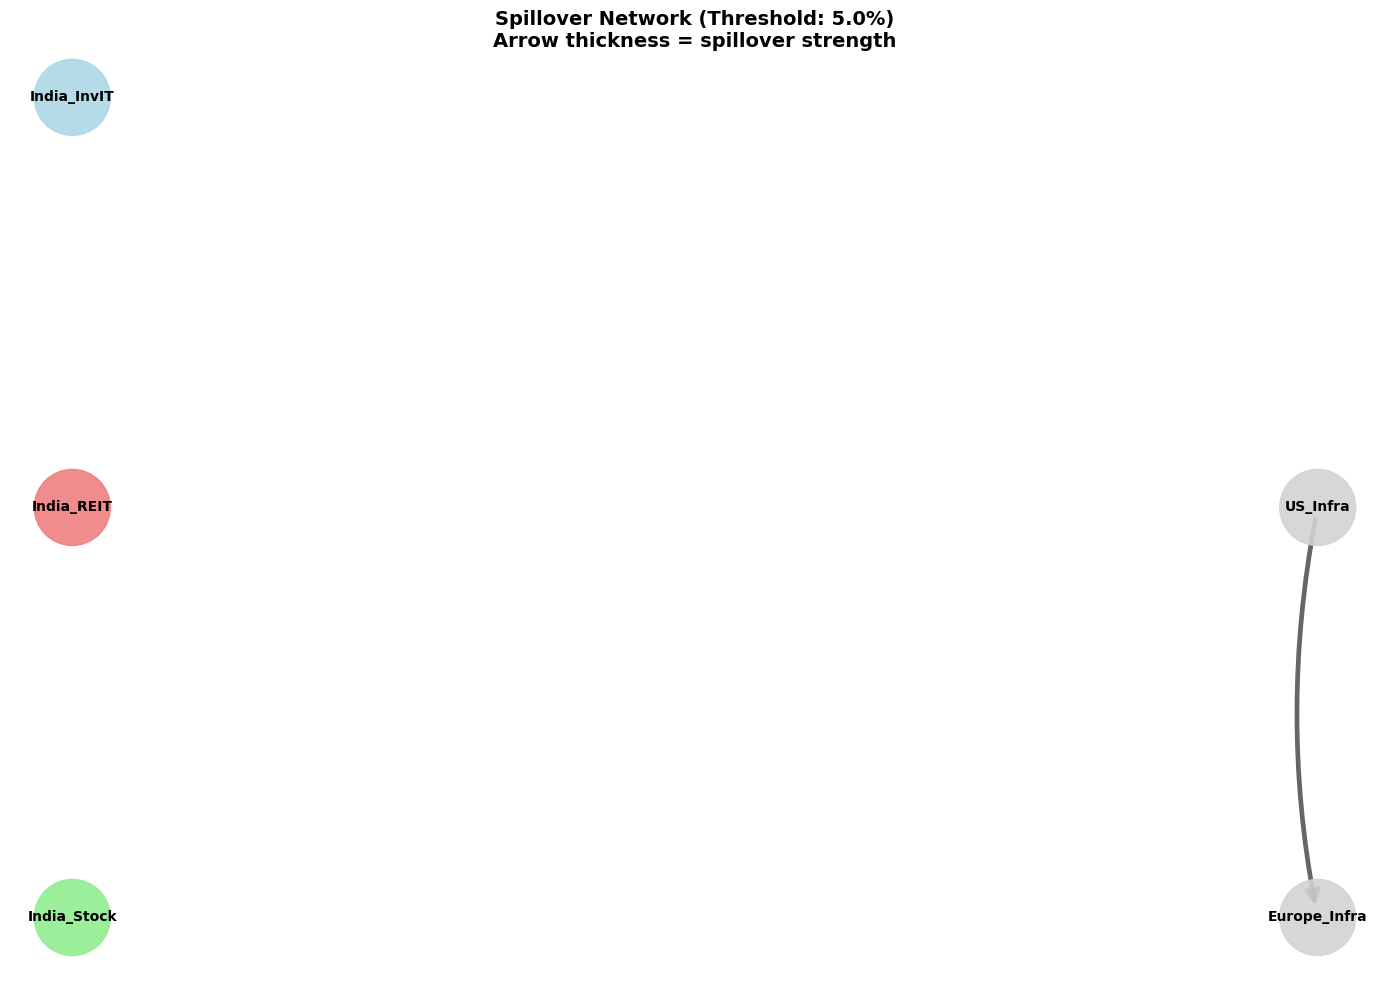

✓ Network plotted (showing spillovers > 5.0%)
  Total significant connections: 1


In [37]:
# CELL 33: Create spillover network visualization

import networkx as nx

print("Creating Spillover Network Visualization:")
print("=" * 80)

# Create directed graph
G = nx.DiGraph()

# Add nodes
nodes = var_data.columns.tolist()
G.add_nodes_from(nodes)

# Add edges (only significant spillovers, e.g., > 5%)
threshold = 5.0  # Only show spillovers > 5%

edges = []
for i, source in enumerate(nodes):
    for j, target in enumerate(nodes):
        if i != j:  # No self-loops
            weight = fevd_df.iloc[j, i] * 100  # Spillover from i to j
            if weight > threshold:
                edges.append((source, target, weight))

G.add_weighted_edges_from(edges)

# Create visualization
plt.figure(figsize=(14, 10))

# Node positions (circular layout with India on left, Foreign on right)
pos = {}
india_nodes = ['India_InvIT', 'India_REIT', 'India_Stock']
foreign_nodes = ['US_Infra', 'Europe_Infra']

# India nodes on left
for i, node in enumerate(india_nodes):
    pos[node] = (-1, 1 - i * 0.5)

# Foreign nodes on right  
for i, node in enumerate(foreign_nodes):
    pos[node] = (1, 0.5 - i * 0.5)

# Node colors
node_colors = []
for node in G.nodes():
    if 'India' in node:
        if 'InvIT' in node:
            node_colors.append('lightblue')
        elif 'REIT' in node:
            node_colors.append('lightcoral')
        else:
            node_colors.append('lightgreen')
    else:
        node_colors.append('lightgray')

# Draw network
nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                       node_size=3000, alpha=0.9)

nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw edges with thickness proportional to spillover strength
for (source, target, weight) in edges:
    nx.draw_networkx_edges(G, pos, [(source, target)],
                          width=weight/5,  # Scale for visibility
                          alpha=0.6,
                          edge_color='black',
                          arrows=True,
                          arrowsize=20,
                          connectionstyle='arc3,rad=0.1')

plt.title(f'Spillover Network (Threshold: {threshold}%)\nArrow thickness = spillover strength', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"✓ Network plotted (showing spillovers > {threshold}%)")
print(f"  Total significant connections: {len(edges)}")

In [38]:
# CELL 34: Summary of key findings - FIXED

print("=" * 80)
print("SPILLOVER ANALYSIS SUMMARY")
print("=" * 80)

print(f"\n1. OVERALL SYSTEM CONNECTEDNESS:")
print(f"   Total Spillover Index: {total_spillover:.2f}%")
if total_spillover < 30:
    print(f"   → Low connectedness (relatively segmented markets)")
elif total_spillover < 60:
    print(f"   → Moderate connectedness (some integration)")
else:
    print(f"   → High connectedness (highly integrated markets)")

print(f"\n2. NET TRANSMITTERS vs RECEIVERS:")
print("-" * 80)
transmitters = spillover_summary[spillover_summary['Role'] == 'Transmitter']
receivers = spillover_summary[spillover_summary['Role'] == 'Receiver']

if len(transmitters) > 0:
    print("   Net Transmitters (send more shocks than receive):")
    for _, row in transmitters.iterrows():
        print(f"     • {row['Variable']:15s}: NET = +{row['NET_%']:5.2f}%")

if len(receivers) > 0:
    print("\n   Net Receivers (receive more shocks than send):")
    for _, row in receivers.iterrows():
        print(f"     • {row['Variable']:15s}: NET = {row['NET_%']:6.2f}%")

print(f"\n3. FOREIGN SPILLOVER TO INDIAN CATEGORIES:")
print("-" * 80)
for _, row in spillover_to_india_df.iterrows():
    print(f"   {row['India_Category']:6s}:")
    print(f"     From US:       {row['FROM_US']:5.2f}%")
    print(f"     From Europe:   {row['FROM_Europe']:5.2f}%")
    print(f"     Total Foreign: {row['FROM_Foreign_Total']:5.2f}%")
    print(f"     Own Variance:  {row['Own_Variance']:5.2f}%")
    print()

print("=" * 80)
print("KEY INSIGHTS FOR YOUR DISSERTATION:")
print("=" * 80)

# Which category receives most foreign spillover?
max_foreign = spillover_to_india_df.loc[spillover_to_india_df['FROM_Foreign_Total'].idxmax()]
min_foreign = spillover_to_india_df.loc[spillover_to_india_df['FROM_Foreign_Total'].idxmin()]

print(f"\n• MOST affected by foreign markets:")
print(f"  {max_foreign['India_Category']} receives {max_foreign['FROM_Foreign_Total']:.2f}% from foreign")

print(f"\n• LEAST affected by foreign markets:")
print(f"  {min_foreign['India_Category']} receives {min_foreign['FROM_Foreign_Total']:.2f}% from foreign")

# Domestic vs Foreign dominance
print(f"\n• Domestic vs Foreign factors:")
for _, row in spillover_to_india_df.iterrows():
    domestic = row['Own_Variance'] + row['FROM_Domestic']
    foreign = row['FROM_Foreign_Total']
    print(f"  {row['India_Category']:6s}: {domestic:5.2f}% domestic, {foreign:5.2f}% foreign")

print("\n" + "=" * 80)
print("✓ PHASE 1 SPILLOVER ANALYSIS COMPLETE")
print("=" * 80)

print("\nWhat we've accomplished:")
print("  ✓ GARCH models for volatility dynamics")
print("  ✓ DCC-GARCH for time-varying correlations")
print("  ✓ Diebold-Yilmaz spillover indices")
print("  ✓ Comparative analysis: InvIT vs REIT vs Stock")

print("\nNext steps (optional enhancements):")
print("  • Rolling-window spillovers (see time dynamics)")
print("  • Volatility regime analysis (crisis vs normal)")
print("  • Export results to tables for dissertation")

SPILLOVER ANALYSIS SUMMARY

1. OVERALL SYSTEM CONNECTEDNESS:
   Total Spillover Index: 6.69%
   → Low connectedness (relatively segmented markets)

2. NET TRANSMITTERS vs RECEIVERS:
--------------------------------------------------------------------------------
   Net Transmitters (send more shocks than receive):
     • India_InvIT    : NET = + 0.73%
     • US_Infra       : NET = + 3.60%

   Net Receivers (receive more shocks than send):
     • India_REIT     : NET =  -0.09%
     • India_Stock    : NET =  -0.64%
     • Europe_Infra   : NET =  -3.60%

3. FOREIGN SPILLOVER TO INDIAN CATEGORIES:
--------------------------------------------------------------------------------
   InvIT :
     From US:        0.32%
     From Europe:    0.02%
     Total Foreign:  0.34%
     Own Variance:  99.44%

   REIT  :
     From US:        1.12%
     From Europe:    0.16%
     Total Foreign:  1.28%
     Own Variance:  96.46%

   Stock :
     From US:        2.39%
     From Europe:    0.10%
     Total Fo

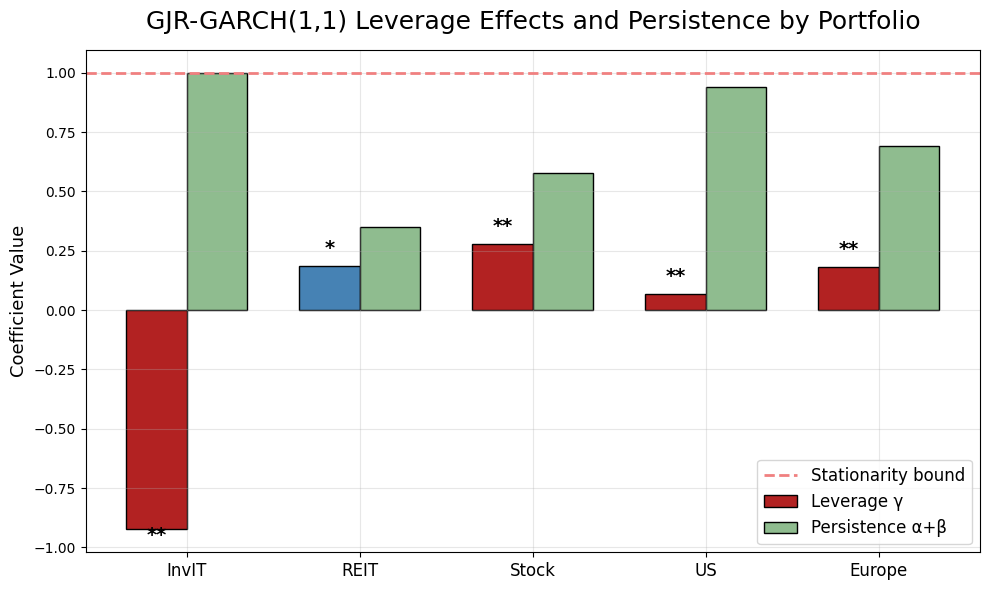

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Portfolio names
portfolios_plot = ['InvIT', 'REIT', 'Stock', 'US', 'Europe']

# Values from Table 5.2
leverage = [-0.924, 0.186, 0.277, 0.069, 0.181]
persistence = [1.000, 0.348, 0.579, 0.941, 0.693]

# Significance levels for colouring
colors = ['firebrick', 'steelblue', 'firebrick', 'firebrick', 'firebrick']

x = np.arange(len(portfolios_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - width/2, leverage, width,
       color=colors,
       edgecolor='black',
       label='Leverage γ')

ax.bar(x + width/2, persistence, width,
       color='darkseagreen',
       edgecolor='black',
       label='Persistence α+β')

# Stationarity bound
ax.axhline(1.0, color='lightcoral', linestyle='--', linewidth=2,
           label='Stationarity bound')

# Significance markers
stars = ['**', '*', '**', '**', '**']
for i, star in enumerate(stars):
    ax.text(x[i]-width/2, leverage[i] + 0.05*np.sign(leverage[i]),
            star,
            ha='center', fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(portfolios_plot, fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=13)
ax.set_title('GJR-GARCH(1,1) Leverage Effects and Persistence by Portfolio',
             fontsize=18, pad=15)

ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

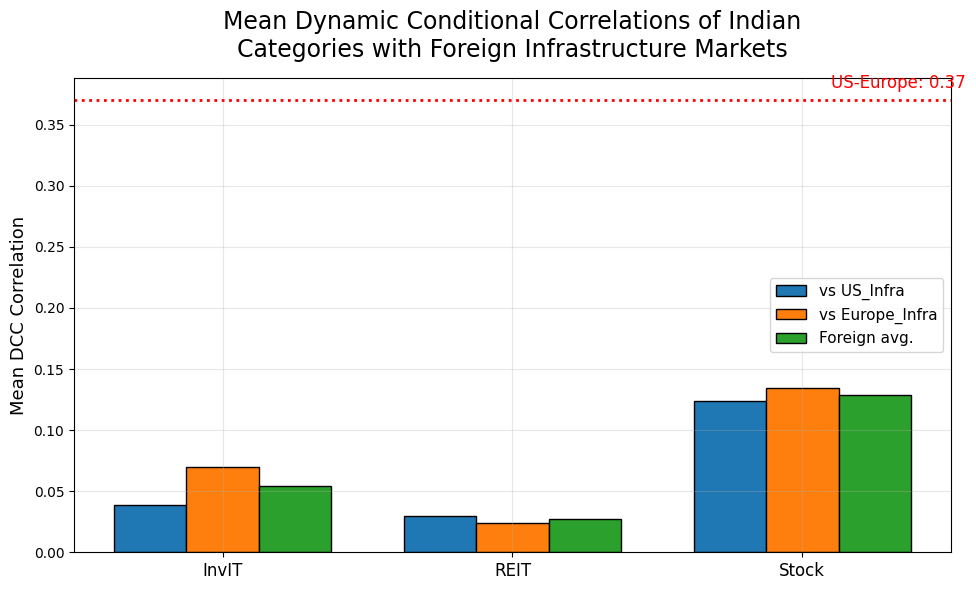

In [42]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['InvIT', 'REIT', 'Stock']

vs_us = [0.0391, 0.0299, 0.1236]
vs_europe = [0.0698, 0.0241, 0.1346]
foreign_avg = [(u+e)/2 for u,e in zip(vs_us, vs_europe)]

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - width, vs_us, width,
       label='vs US_Infra', edgecolor='black')

ax.bar(x, vs_europe, width,
       label='vs Europe_Infra', edgecolor='black')

ax.bar(x + width, foreign_avg, width,
       label='Foreign avg.', edgecolor='black')

# Benchmark line
benchmark = 0.37
ax.axhline(benchmark, color='red', linestyle=':', linewidth=2)
ax.text(2.1, benchmark+0.01, 'US-Europe: 0.37',
        color='red', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Mean DCC Correlation', fontsize=13)

ax.set_title('Mean Dynamic Conditional Correlations of Indian\nCategories with Foreign Infrastructure Markets',
             fontsize=17, pad=15)

ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

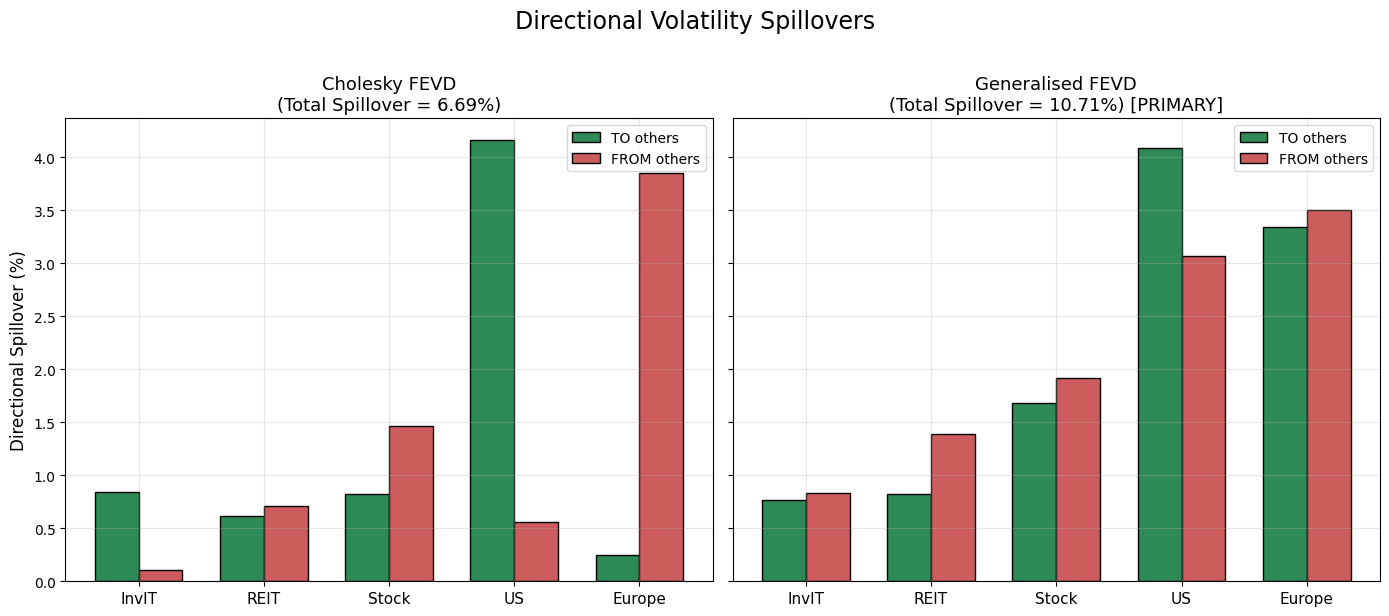

In [49]:
import matplotlib.pyplot as plt
import numpy as np

variables = ['InvIT', 'REIT', 'Stock', 'US', 'Europe']

# Cholesky spillovers
chol_to = [0.84, 0.62, 0.82, 4.16, 0.25]
chol_from = [0.11, 0.71, 1.46, 0.56, 3.85]

# Generalised spillovers
gen_to = [0.77, 0.82, 1.68, 4.09, 3.34]
gen_from = [0.83, 1.39, 1.92, 3.07, 3.50]

x = np.arange(len(variables))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Panel A — Cholesky
axes[0].bar(x - width/2, chol_to, width,
            color='seagreen', edgecolor='black', label='TO others')
axes[0].bar(x + width/2, chol_from, width,
            color='indianred', edgecolor='black', label='FROM others')

axes[0].set_xticks(x)
axes[0].set_xticklabels(variables, fontsize=11)
axes[0].set_ylabel('Directional Spillover (%)', fontsize=12)
axes[0].set_title('Cholesky FEVD\n(Total Spillover = 6.69%)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Panel B — Generalised
axes[1].bar(x - width/2, gen_to, width,
            color='seagreen', edgecolor='black', label='TO others')
axes[1].bar(x + width/2, gen_from, width,
            color='indianred', edgecolor='black', label='FROM others')

axes[1].set_xticks(x)
axes[1].set_xticklabels(variables, fontsize=11)
axes[1].set_title('Generalised FEVD\n(Total Spillover = 10.71%) [PRIMARY]', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

fig.suptitle('Directional Volatility Spillovers',
             fontsize=17, y=1.02)

plt.tight_layout()
plt.show()

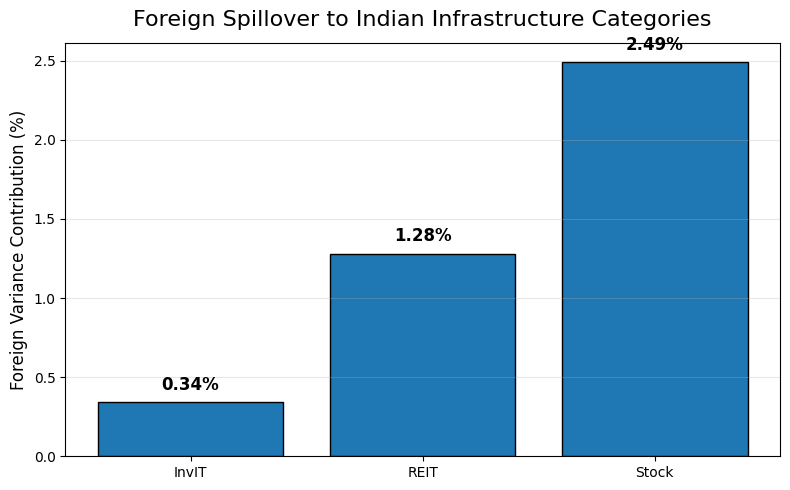

In [45]:
import matplotlib.pyplot as plt

categories = ['InvIT', 'REIT', 'Stock']
foreign_spillover = [0.34, 1.28, 2.49]
own_variance = [99.44, 96.46, 92.72]

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(categories, foreign_spillover,
              edgecolor='black')

for i, val in enumerate(foreign_spillover):
    ax.text(i, val + 0.08, f'{val:.2f}%',
            ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Foreign Variance Contribution (%)', fontsize=12)
ax.set_title('Foreign Spillover to Indian Infrastructure Categories',
             fontsize=16, pad=12)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

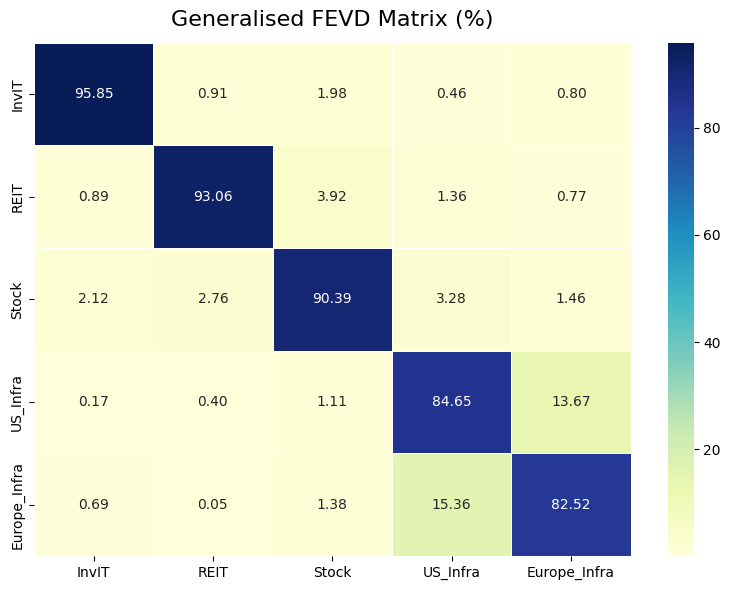

In [46]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

fevd_matrix = pd.DataFrame([
    [95.85, 0.91, 1.98, 0.46, 0.80],
    [0.89, 93.06, 3.92, 1.36, 0.77],
    [2.12, 2.76, 90.39, 3.28, 1.46],
    [0.17, 0.40, 1.11, 84.65, 13.67],
    [0.69, 0.05, 1.38, 15.36, 82.52]
],
index=['InvIT', 'REIT', 'Stock', 'US_Infra', 'Europe_Infra'],
columns=['InvIT', 'REIT', 'Stock', 'US_Infra', 'Europe_Infra'])

plt.figure(figsize=(8,6))

sns.heatmap(fevd_matrix,
            annot=True,
            fmt='.2f',
            cmap='YlGnBu',
            linewidths=0.5)

plt.title('Generalised FEVD Matrix (%)', fontsize=16, pad=12)
plt.tight_layout()
plt.show()